<a href="https://colab.research.google.com/github/martinruhle/curso-ciencia-datos-2027-1/blob/lab03/eda_cohorte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 03 — EDA sobre una cohorte de diabetes tipo 2

**Sesión 03:** Python para Biomedicina: Visualización y Análisis Exploratorio

Continúa el dataset de Synthea del lab02 (23 018 pacientes, 17 355 578 observaciones).
Se define una cohorte clínica, se ejecuta el checklist de EDA de la sesión y se producen
figuras publicables.

> **Regla de trabajo, heredada del lab02.** Los filtros clínicos se hacen **por código**
> (SNOMED / LOINC), nunca por subcadena de la descripción. La búsqueda por texto se usa
> únicamente para *descubrir* qué códigos existen; la definición de cohorte y de analito
> se ancla en el código. Es el mismo principio que sostiene el uso de vocabularios
> estándar en OMOP y el que evitó, en el lab02, mezclar el IMC en razón con el percentil
> pediátrico.


## 0. Entorno

### 0.1 Dependencias

`tableone` genera la tabla de características basales; `lifelines` es opcional (curva
de Kaplan–Meier de la sección extra). El resto viene preinstalado en Colab.


In [53]:
!pip install -q tableone lifelines


### 0.2 Módulo de funciones puras

Las funciones sin estado (normalización de fechas, edad en la fecha índice, ventana
basal, atrición) viven en `eda_utils.py`, no en el notebook. Motivo: el criterio de
evaluación pide que `ruff check` y `pytest` pasen, y un `.ipynb` no es testeable.
Subí `eda_utils.py` y `test_eda_utils.py` al mismo directorio que este notebook (ajustando `sys.path`).


In [54]:
import sys
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

# Los .py están en Drive junto al notebook, se agrega su carpeta al path:
sys.path.insert(0, '/content/drive/MyDrive/curso-cd-2027/lab03')

from eda_utils import (
    a_dia_naive,
    a_dia_naive_escalar,
    edad_en_fecha,
    marcar_implausibles,
    tabla_atricion,
    valor_basal,
)
print('eda_utils importado OK')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
eda_utils importado OK


In [55]:
# Verificación de la calidad del código (criterio de evaluación del lab)
!pip install -q ruff pytest

# Se mueve el cwd del notebook
%cd /content/drive/MyDrive/curso-cd-2027/lab03
!ruff check eda_utils.py test_eda_utils.py
!python -m pytest test_eda_utils.py -q


/content/drive/MyDrive/curso-cd-2027/lab03
All checks passed!
..........                                                               [100%]
10 passed in 3.11s


### 0.3 Rutas y carga del estado del lab02

El lab02 dejó tres DataFrames ya tipados en `ckpt/` (Parquet, que conserva el esquema:
`category`, `float32` y `datetime64[ns, UTC]` vuelven intactos). Este laboratorio los
**consume sin modificarlos** y agrega una tabla que el lab02 nunca cargó:
`conditions.csv`.


In [56]:
import gc

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE02 = Path('/content/drive/MyDrive/curso-cd-2027/lab02')
BASE03 = Path('/content/drive/MyDrive/curso-cd-2027/lab03')
DATA   = BASE02 / 'data'      # CSV originales de Synthea
CKPT   = BASE02 / 'ckpt'      # checkpoints tipados del lab02
FIG    = BASE03 / 'figuras'   # entregable del lab03
FIG.mkdir(parents=True, exist_ok=True)

assert (CKPT / 'obs.parquet').exists(), 'Falta el checkpoint del lab02'
assert (DATA / 'conditions.csv').exists(), 'Falta conditions.csv en DATA'
print('rutas OK')


rutas OK


In [57]:
obs = pd.read_parquet(CKPT / 'obs.parquet')
p8  = pd.read_parquet(CKPT / 'p8.parquet')
enc = pd.read_parquet(CKPT / 'enc_tip.parquet')

print('observations:', obs.shape)
print('patients    :', p8.shape)
print('encounters  :', enc.shape)
print()
print(obs.dtypes)


observations: (17355578, 10)
patients    : (23018, 8)
encounters  : (1355775, 7)

DATE           datetime64[ns, UTC]
PATIENT                   category
ENCOUNTER                 category
CATEGORY                  category
CODE                      category
DESCRIPTION               category
UNITS                     category
TYPE                      category
VALUE_num                  float32
VALUE_cat                 category
dtype: object


### 0.4 `conditions.csv` — la tabla nueva, y su trampa de tipos

Los códigos de `conditions` son **SNOMED CT**, y a diferencia de LOINC son cadenas de
dígitos sin separadores. Si se deja inferir el tipo, pandas los lee como `int64`: se
pierden los ceros a la izquierda si los hubiera y, sobre todo, se convierte un
identificador en un número sobre el que tiene sentido calcular medias. Se fuerza `str`
en la lectura y se convierte a `category` después.

También se lee la lista de columnas primero: distintas versiones de Synthea exportan
una columna `SYSTEM` adicional, y un `usecols` fijo rompería con las versiones que no
la tienen.


In [58]:
cols_disponibles = pd.read_csv(DATA / 'conditions.csv', nrows=0).columns.tolist()
print('columnas en conditions.csv:', cols_disponibles)

deseadas = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']
usar = [c for c in deseadas if c in cols_disponibles]

cond = pd.read_csv(
    DATA / 'conditions.csv',
    usecols=usar,
    dtype={'CODE': str, 'DESCRIPTION': 'category'},   # CODE es identificador, no número
    parse_dates=['START', 'STOP'],
)
cond['CODE'] = cond['CODE'].astype('category')
cond['PATIENT'] = cond['PATIENT'].astype(str)
cond['START'] = a_dia_naive(cond['START'])
cond['STOP'] = a_dia_naive(cond['STOP'])

print('\nconditions:', cond.shape)
print('pacientes con al menos una condición:', cond['PATIENT'].nunique())
cond.head()


columnas en conditions.csv: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION']

conditions: (835138, 6)
pacientes con al menos una condición: 23018


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2018-08-17,2018-08-17,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-4314-63c7f408666f,314529007,Medication review due (situation)
1,2018-09-21,2019-04-26,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-9997-d877d0d3c58e,314529007,Medication review due (situation)
2,2019-07-26,2019-10-25,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-89e6-a4b5a85b7e57,314529007,Medication review due (situation)
3,2019-10-01,2019-11-24,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-3dc2-b108b2dc542e,90460009,Injury of neck (disorder)
4,2019-10-01,2019-11-24,e82ce5d7-a72c-7886-8c2b-42b8641f8448,e82ce5d7-a72c-7886-3dc2-b108b2dc542e,39848009,Whiplash injury to neck (disorder)


### 0.5 Estilo de figura

Se fija una única vez el estilo para todo el notebook, de modo que ninguna figura
dependa de ajustes ad hoc. Cuatro decisiones que importan para los criterios de
evaluación:

- **`pdf.fonttype = 42`** — matplotlib exporta a PDF con fuentes Type 3 por defecto, que
  muchas revistas rechazan y que Illustrator no puede editar. El 42 fuerza TrueType.
- **Paleta cualitativa `colorblind` de seaborn** y secuencial **`viridis`**: ambas son
  perceptualmente uniformes y sobreviven al daltonismo y a la impresión en gris. El
  criterio del lab lo exige explícitamente.
- **`constrained_layout`** en lugar de `tight_layout`: resuelve el solapamiento de
  etiquetas de forma determinista en figuras multipanel.
- **Tamaño en pulgadas y tipografía de 8–10 pt**: una figura de una columna de revista
  mide ~3.5 in de ancho, una de dos columnas ~7.2 in. Diseñar a ese tamaño evita el
  error clásico de una figura enorme reducida al 30 %, donde la tipografía queda
  ilegible.

> **Nota sobre la fuente.** Colab no trae Arial ni Helvetica; se usa DejaVu Sans, que es
> la de matplotlib. Si la revista exige Arial, hay que instalarla y limpiar la caché de
> fuentes.


In [59]:
sns.set_theme(context='paper', style='ticks')

PALETA = sns.color_palette('colorblind')
COLOR_SEXO = {'M': PALETA[0], 'F': PALETA[1]}
CMAP = 'viridis'          # secuencial, perceptualmente uniforme

ANCHO_1COL = 3.5          # pulgadas — una columna de revista
ANCHO_2COL = 7.2          # dos columnas

# Unidades por analito. Existen para que NINGUNA figura tenga un eje sin unidad,
# que es el primer criterio de evaluación del laboratorio.
UNIDADES = {
    'HbA1c': '%', 'IMC': 'kg/m²', 'Peso': 'kg', 'Talla': 'cm',
    'PA sistólica': 'mmHg', 'PA diastólica': 'mmHg',
    'Frecuencia cardíaca': 'lpm', 'Frecuencia respiratoria': 'rpm',
    'Glucosa': 'mg/dL', 'Colesterol total': 'mg/dL', 'HDL': 'mg/dL',
    'LDL': 'mg/dL', 'Triglicéridos': 'mg/dL', 'Creatinina': 'mg/dL',
}

plt.rcParams.update({
    'figure.dpi': 110,            # en pantalla
    'savefig.dpi': 300,           # en disco
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,           # TrueType, no Type 3
    'ps.fonttype': 42,
    'font.size': 9,
    'axes.titlesize': 9.5,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'figure.constrained_layout.use': True,
})
print('estilo fijado |', len(UNIDADES), 'analitos con unidad declarada')


estilo fijado | 14 analitos con unidad declarada


---
## Actividad 1 — Definición de la cohorte

Una cohorte no es un filtro: es una **definición** con cuatro componentes que hay que
declarar antes de escribir código. Es la estructura que se formaliza en ATLAS/OHDSI y
que se retomará en la sesión 17.

1. **Evento de entrada** — qué hecho clínico hace que un paciente entre.
2. **Fecha índice** — el instante desde el que se cuenta todo lo demás.
3. **Criterios de inclusión/exclusión** — evaluados *en relación con* la fecha índice.
4. **Fin de seguimiento** — hasta cuándo se observa a cada paciente.

Sin fecha índice no hay cohorte: hay una lista de pacientes. Toda la Actividad 3
(evolución temporal) y toda la Tabla 1 (características *basales*) dependen de ella.


### 1.1 Descubrimiento: qué códigos existen

Este paso es **exploratorio**, y por eso sí usa búsqueda por texto. La búsqueda por
subcadena sirve para saber qué hay; no sirve para definir la cohorte.


In [60]:
resumen_cond = (
    cond.groupby('CODE', observed=True)
        .agg(descripcion=('DESCRIPTION', 'first'),
             n_registros=('PATIENT', 'size'),
             n_pacientes=('PATIENT', 'nunique'))
        .sort_values('n_pacientes', ascending=False)
)
print('códigos SNOMED distintos:', len(resumen_cond))
resumen_cond.head(25)


códigos SNOMED distintos: 313


,descripcion,n_registros,n_pacientes
CODE,,,
314529007,Medication review due (situation),164772,23018
66383009,Gingivitis (disorder),62287,18560
73595000,Stress (finding),65167,18115
160903007,Full-time employment (finding),59732,18096
444814009,Viral sinusitis (disorder),23575,14701
160904001,Part-time employment (finding),37557,14676
422650009,Social isolation (finding),23062,12368
423315002,Limited social contact (finding),23107,12310
162864005,Body mass index 30+ - obesity (finding),10993,10993


In [61]:
# Descubrimiento por texto: SOLO para ver qué candidatos hay
patron = 'diabet|glycem|glucos|hyperglyc'
candidatos = resumen_cond[
    resumen_cond['descripcion'].astype(str).str.contains(patron, case=False, regex=True)
]
candidatos


,descripcion,n_registros,n_pacientes
CODE,,,
714628002,Prediabetes (finding),8768,8768
127013003,Disorder of kidney due to diabetes mellitus (d...,2270,2270
90781000119102,Microalbuminuria due to type 2 diabetes mellit...,1910,1910
44054006,Diabetes mellitus type 2 (disorder),1751,1751
157141000119108,Proteinuria due to type 2 diabetes mellitus (d...,1354,1354
80394007,Hyperglycemia (disorder),816,816
368581000119106,Neuropathy due to type 2 diabetes mellitus (di...,547,547
1551000119108,Nonproliferative diabetic retinopathy due to t...,430,430
97331000119101,Macular edema and retinopathy due to type 2 di...,45,45


**Lo que muestra esta celda es exactamente el riesgo.** Un filtro
`str.contains('diabetes')` barrería en la misma bolsa la diabetes tipo 1, la tipo 2, la
prediabetes y las complicaciones. Las poblaciones tienen edades, tratamientos y pronósticos
distintos. Mezclarlas produce una cohorte cuyo "efecto" es un promedio de fenómenos que
no comparten mecanismo.

### 1.2 La definición, declarada

**Evento de entrada:** primer registro en `conditions` con SNOMED CT `44054006`
(*Diabetes mellitus type 2 — disorder*).

**Fecha índice:** `START` de ese primer registro.

**Criterios:**

| Criterio | Umbral | Por qué |
|---|---|---|
| Edad en la fecha índice | ≥ 18 años | La T2D pediátrica es una entidad distinta y en Synthea es rarísima; incluirla agrega una subpoblación con otra fisiopatología. |
| Seguimiento posterior al índice | ≥ 365 días | Sin al menos un año de observación no hay evolución temporal que describir (Actividad 3). |

**Fin de seguimiento:** `min(DEATHDATE, fecha máxima del dataset)`. Es el análogo del
`observation_period` de OMOP: nadie puede ser observado después de que se cortaron los
datos.

> **Sesgo que introduce el segundo criterio, y hay que decirlo.** Exigir 365 días de
> seguimiento excluye a quien murió en el primer año tras el diagnóstico — es decir,
> sistemáticamente a los pacientes más graves. Es **sesgo de supervivencia**, y no es
> gratuito: cualquier estimación de mortalidad sobre esta cohorte estará sesgada a la
> baja. Lo acepto porque el objetivo del lab es describir trayectorias longitudinales,
> que sin seguimiento no existen, pero queda registrado como limitación. La alternativa
> —no exigir seguimiento— produciría una cohorte donde una fracción de los pacientes
> aporta un solo punto temporal.


In [62]:
CODIGO_COHORTE = '44054006'   # SNOMED CT: Diabetes mellitus type 2 (disorder)

assert CODIGO_COHORTE in set(resumen_cond.index), (
    'El código no está en el dataset. Revisá la celda de descubrimiento: tu versión '
    'de Synthea puede usar otro concepto.'
)
print(resumen_cond.loc[CODIGO_COHORTE])


descripcion    Diabetes mellitus type 2 (disorder)
n_registros                                   1751
n_pacientes                                   1751
Name: 44054006, dtype: object


In [63]:
dx = cond[cond['CODE'] == CODIGO_COHORTE]
indice = (dx.groupby('PATIENT', observed=True)['START']
            .min()
            .rename('fecha_indice')
            .reset_index())

print('pacientes con el evento de entrada:', len(indice))
print('rango de fechas índice:', indice['fecha_indice'].min().date(),
      '→', indice['fecha_indice'].max().date())


pacientes con el evento de entrada: 1751
rango de fechas índice: 1942-12-28 → 2026-08-19


### 1.3 Ensamblado y tabla de atrición

La tabla de atrición es el equivalente numérico del diagrama de flujo que pide la
sesión: cuántos pacientes se pierden en cada paso y por qué. En un manuscrito clínico
es obligatoria (CONSORT/STROBE), y en OHDSI es lo que produce la *attrition table* de
la sesión 18.


In [64]:
FIN_DATOS = a_dia_naive_escalar(obs['DATE'].max())
print('última fecha observada en el dataset:', FIN_DATOS.date())

pac = (p8.rename(columns={'Id': 'PATIENT'})
         [['PATIENT', 'BIRTHDATE', 'DEATHDATE', 'GENDER', 'RACE', 'ETHNICITY', 'CITY']]
         .copy())
pac['PATIENT'] = pac['PATIENT'].astype(str)
pac['BIRTHDATE'] = a_dia_naive(pac['BIRTHDATE'])
pac['DEATHDATE'] = a_dia_naive(pac['DEATHDATE'])

coh = pac.merge(indice, on='PATIENT', how='inner', validate='1:1')

coh['edad_indice'] = edad_en_fecha(coh['BIRTHDATE'], coh['fecha_indice'])
coh['fin_seguimiento'] = coh['DEATHDATE'].fillna(FIN_DATOS).clip(upper=FIN_DATOS)
coh['dias_seguimiento'] = (coh['fin_seguimiento'] - coh['fecha_indice']).dt.days
coh['fallecido'] = coh['DEATHDATE'].notna()

print('shape tras el join:', coh.shape)
coh[['edad_indice', 'dias_seguimiento']].describe().round(1)


última fecha observada en el dataset: 2026-08-27
shape tras el join: (1751, 12)


,edad_indice,dias_seguimiento
count,1751.0,1751.0
mean,47.3,6403.7
std,11.8,4916.8
min,11.0,8.0
25%,40.0,2569.5
50%,46.6,5407.0
75%,55.1,8993.0
max,94.7,28679.0


### 1.3b Caracterización del período con datos disponibles

Antes de aplicar ningún criterio hay que establecer **qué ventana temporal está
efectivamente cubierta por los datos**. No es un detalle de implementación: es la
diferencia entre el tiempo *transcurrido* y el tiempo *observado*, y confundirlos es
uno de los errores más caros en estudios con datos del mundo real. Un paciente
diagnosticado en 1985 y fallecido en 2020 acumula 35 años de "seguimiento" que no
significan nada si en 30 de esos años no existe un solo registro.

OMOP CDM resuelve esto con una tabla dedicada, `observation_period`, que se puebla
**antes** de definir cualquier cohorte y que ATLAS consulta en cada criterio temporal.
Acá se reconstruye ese concepto de forma empírica: se mide cuándo empiezan los datos,
en lugar de suponerlo.

In [65]:
# ── Caracterización empírica del período con datos ────────────────────────────
# Se mide sobre `obs` COMPLETO (23 018 pacientes), no sobre la cohorte: la ventana
# de exportación es una propiedad del dataset y no debe estimarse sobre un subconjunto
# ya filtrado, que la sesgaría.

por_anio = obs['DATE'].dt.year.value_counts().sort_index()

# Detección del escalón: mayor salto relativo interanual a partir de 1990
razon = (por_anio / por_anio.shift(1))
anio_salto = int(razon.loc[razon.index >= 1990].idxmax())

# Criterio alternativo, menos sensible a un año atípico: primer año que alcanza el 50 %
# del volumen mediano de los últimos cinco años completos
nivel = por_anio.loc[FIN_DATOS.year - 5:FIN_DATOS.year - 1].median()
anio_50 = int(por_anio[por_anio >= 0.5 * nivel].index.min())

print(f'salto interanual máximo en : {anio_salto}')
print(f'primer año al 50 % del nivel: {anio_50}')
print('\nregistros por año alrededor del salto:')
print(por_anio.loc[anio_salto - 4:anio_salto + 4].to_string())

# ── Historia exportada por paciente ──────────────────────────────────────────
span = obs.groupby('PATIENT', observed=True)['DATE'].agg(['min', 'max'])
span['anios'] = (span['max'] - span['min']).dt.days / 365.25
fallecidos = set(p8.loc[p8['DEATHDATE'].notna(), 'Id'].astype(str))
span['fallecido'] = span.index.astype(str).isin(fallecidos)

print('\nextensión de la historia exportada por paciente (años):')
print(span.groupby('fallecido')['anios'].describe(percentiles=[.5, .95]).round(1))

# ── Evidencia de que `conditions` NO sufre la misma truncación ───────────────
print('\nprimer diagnóstico de T2D registrado:', indice['fecha_indice'].min().date())
print('primera observación registrada      :',
      a_dia_naive_escalar(obs['DATE'].min()).date())

salto interanual máximo en : 2016
primer año al 50 % del nivel: 2017

registros por año alrededor del salto:
DATE
2012     176630
2013     188405
2014     195955
2015     191657
2016     554510
2017    1178544
2018    1209977
2019    1232442
2020    1410407

extensión de la historia exportada por paciente (años):
             count  mean  std  min   50%   95%   max
fallecido                                           
False      20001.0   9.3  1.9  0.0  10.0  10.3  10.6
True        3017.0   9.2  1.5  0.1   9.6  10.1  10.9

primer diagnóstico de T2D registrado: 1942-12-28
primera observación registrada      : 1915-10-21


### 1.3c El cuarto criterio: la fecha índice dentro del período observado

Los tres criterios anteriores son *nominales*: se cumplen sobre las fechas, sin
verificar que exista dato alguno en ellas. La caracterización anterior muestra que el
registro efectivo abarca aproximadamente la última década, de modo que un paciente
diagnosticado antes de esa ventana entra a la cohorte sin ninguna medición cercana a
su fecha índice.

**El criterio.** La fecha índice debe caer dentro del período con datos, con al menos
365 días de historia previa disponible. El requisito de historia previa no es
arbitrario: es exactamente el `lookback` de la ventana basal
(`valor_basal(lookback=-365)`) y de la definición de comorbilidad prevalente. Sin él,
"valor basal" y "comorbilidad previa al diagnóstico" son categorías vacías para una
parte de la cohorte, y el faltante resultante se confundiría con ausencia clínica
cuando en realidad es ausencia de exportación.

Es el análogo directo del criterio `prior observation` que ATLAS exige en toda
definición de cohorte de OHDSI, y la razón por la que existe.

**El costo, y es grande.** Este criterio reduce la cohorte de forma severa, porque la
mayoría de los diagnósticos de T2D del dataset ocurrieron antes de la ventana
exportada. La alternativa —conservar 1682 pacientes de los cuales dos tercios no
tienen ninguna medición en su ventana basal— produce una Tabla 1 construida sobre el
32 % de la cohorte sin declararlo, y una matriz de correlación calculada sobre una
subpoblación seleccionada. Prefiero una cohorte chica y observada a una grande y
hueca, y dejo la decisión documentada como tal.

In [66]:
# ── Tabla de atrición (cuatro criterios) ─────────────────────────────────────
# El detector de escalón identifica el AÑO; la evidencia de `span` identifica la REGLA.
# Se usa la regla, que es más precisa y además explica el año de transición.
ANIOS_HISTORIA = 10                                   # verificado: span máx = 10.9 años
VENTANA_INICIO = FIN_DATOS - pd.DateOffset(years=ANIOS_HISTORIA)
LOOKBACK_BASAL = 365

inicio_elegible = VENTANA_INICIO + pd.Timedelta(days=LOOKBACK_BASAL)
print(f'ventana con datos      : {VENTANA_INICIO.date()} → {FIN_DATOS.date()}')
print(f'fechas índice elegibles: {inicio_elegible.date()} → '
      f'{(FIN_DATOS - pd.Timedelta(days=365)).date()}')

pasos = [('Pacientes en el dataset', len(pac))]

p_dx = coh
pasos.append((f'Con dx de T2D (SNOMED {CODIGO_COHORTE})', len(p_dx)))

p_adulto = p_dx[p_dx['edad_indice'] >= 18]
pasos.append(('Edad >= 18 años en la fecha índice', len(p_adulto)))

p_seg = p_adulto[p_adulto['dias_seguimiento'] >= 365]
pasos.append(('Con >= 365 días de seguimiento post-índice', len(p_seg)))

p_obs = p_seg[p_seg['fecha_indice'] >= inicio_elegible]
pasos.append((f'Índice dentro del período observado (>= {inicio_elegible.date()})',
              len(p_obs)))

atricion = tabla_atricion(pasos)
p_final = p_obs        # nombre que consume la celda siguiente, sin cambios

if len(p_final) < 100:
    print('AVISO: cohorte < 100 pacientes. Ver la nota sobre alternativas.\n')

atricion

ventana con datos      : 2016-08-27 → 2026-08-27
fechas índice elegibles: 2017-08-27 → 2025-08-27


,paso,n,excluidos,pct_del_inicial
0,Pacientes en el dataset,23018,0,100.0
1,Con dx de T2D (SNOMED 44054006),1751,21267,7.6
2,Edad >= 18 años en la fecha índice,1750,1,7.6
3,Con >= 365 días de seguimiento post-índice,1682,68,7.3
4,Índice dentro del período observado (>= 2017-0...,395,1287,1.7


In [67]:
coh = p_final.reset_index(drop=True).copy()
COHORTE = set(coh['PATIENT'])
print('cohorte final:', len(COHORTE), 'pacientes')

# Sanidad: la fecha índice nunca puede ser anterior al nacimiento ni posterior al fin
assert (coh['fecha_indice'] >= coh['BIRTHDATE']).all()
assert (coh['fecha_indice'] <= coh['fin_seguimiento']).all()
print('chequeos de coherencia temporal OK')


cohorte final: 395 pacientes
chequeos de coherencia temporal OK


**Atrición.** De los 23 018 pacientes del dataset, 1751 (7.6 %) registran al menos un
diagnóstico de diabetes mellitus tipo 2 (SNOMED CT 44054006). Esa cifra es la
prevalencia acumulada de T2D en la población simulada, no una pérdida de cohorte. Los
dos criterios clínicos convencionales excluyen muy poco: el de edad ≥ 18 años en la
fecha índice descarta **un solo paciente** (diagnóstico a los 11 años) y el de ≥ 365
días de seguimiento posterior al índice descarta **68 (3.9 %)**. El sesgo de
supervivencia que introduce este último queda por lo tanto acotado, muy por debajo del
10 % que se había fijado como umbral de preocupación.

**El cuarto criterio es el que reconfigura la cohorte.** Exigir que la fecha índice
caiga dentro del período con datos efectivamente exportados, con al menos 365 días de
historia previa, excluye **1287 pacientes: el 76.5 % de los que habían superado los
tres criterios anteriores.** La cohorte final es de **395 pacientes (1.7 % del
dataset)**.

Una exclusión de esa magnitud exige justificación, y la justificación es que los tres
primeros criterios son **nominales**: se evalúan sobre fechas sin verificar que exista
un dato en ellas. La caracterización del período de observación mostró que Synthea
exporta únicamente los últimos diez años de historia de cada paciente
(`exporter.years_of_history = 10`; extensión máxima observada 10.9 años sobre 23 018
pacientes, sin una sola excepción), mientras que la tabla de condiciones conserva
fechas de diagnóstico que se remontan a 1942. La consecuencia era que 1287 pacientes
entraban a la cohorte con una fecha índice válida y **ninguna medición alrededor de
ella**.

**La verificación es directa y es la que valida la decisión.** Con los tres criterios
previos, sólo el **31.8 %** de la cohorte tenía algún valor en la ventana basal de
[índice − 365 d, índice + 30 d]. Con el cuarto criterio la cobertura basal es del
**100 % en los catorce analitos**. La cohorte pasó de 1682 pacientes de los cuales dos
tercios no tenían datos utilizables a 395 pacientes íntegramente observados. La Tabla 1,
la matriz de correlación y toda la sección de características basales se construyen
ahora sobre la cohorte completa y no sobre un tercio no declarado de ella.

**Lo que este criterio cuesta.** La cohorte queda restringida a diagnósticos incidentes
de los últimos años del período simulado, y el seguimiento máximo cae de 78.5 a **9.0
años** (mediana 4.9). Cualquier análisis longitudinal a más de ese plazo queda fuera de
alcance. Además no es una muestra aleatoria de los diabéticos del dataset: son los
diagnosticados más recientemente. Es el compromiso explícito entre tamaño y
observabilidad, y se elige observabilidad, porque una cohorte grande sin datos no es
una cohorte grande sino una tabla de identificadores.

> **Nota sobre la fecha de corte.** `VENTANA_INICIO` se deriva de la regla verificada
> (`FIN_DATOS − 10 años`) y no del detector de escalón, que sólo identifica el año. La
> diferencia no es cosmética: con el 1 de enero de 2016 la primera fecha índice
> elegible habría tenido cuatro meses de historia previa, no los 365 días que el
> criterio afirma garantizar.


### 1.4 Observaciones de la cohorte

Se restringe `observations` (17.4 M filas) a los pacientes de la cohorte y a un conjunto
declarado de analitos, identificados **por código LOINC**. Se verifica que cada código
exista antes de filtrar: un código ausente produciría una serie vacía sin levantar
error, que es la clase de fallo silencioso más cara del lab02.


In [68]:
LOINC = {
    '4548-4':  'HbA1c',
    '39156-5': 'IMC',
    '29463-7': 'Peso',
    '8302-2':  'Talla',
    '8480-6':  'PA sistólica',
    '8462-4':  'PA diastólica',
    '8867-4':  'Frecuencia cardíaca',
    '9279-1':  'Frecuencia respiratoria',
    '2339-0':  'Glucosa',
    '2093-3':  'Colesterol total',
    '2085-9':  'HDL',
    '18262-6': 'LDL',
    '2571-8':  'Triglicéridos',
    '38483-4': 'Creatinina',
}

codigos_presentes = set(obs['CODE'].cat.categories)
faltantes = [c for c in LOINC if c not in codigos_presentes]
print('códigos LOINC ausentes en el dataset (revisar, NO ignorar):', faltantes)

LOINC = {k: v for k, v in LOINC.items() if k in codigos_presentes}
print('analitos utilizables:', len(LOINC))


códigos LOINC ausentes en el dataset (revisar, NO ignorar): []
analitos utilizables: 14


In [69]:
obs_c = obs[obs['CODE'].isin(list(LOINC)) & obs['PATIENT'].isin(COHORTE)].copy()

for c in obs_c.select_dtypes('category').columns:
    obs_c[c] = obs_c[c].cat.remove_unused_categories()

# Mismo costo ergonómico de `category` que en la Actividad 4 del lab02: excelente en
# reposo, incómodo para unir. Se castea la clave a str de forma EXPLÍCITA en lugar de
# dejar que pandas upcastee en silencio durante el merge.
obs_c['PATIENT'] = obs_c['PATIENT'].astype(str)

obs_c['analito'] = obs_c['CODE'].map(LOINC).astype('category')
obs_c['FECHA'] = a_dia_naive(obs_c['DATE'])
obs_c = obs_c.merge(coh[['PATIENT', 'fecha_indice', 'GENDER', 'edad_indice']],
                    on='PATIENT', how='left', validate='m:1')
obs_c['dias_desde_indice'] = (obs_c['FECHA'] - obs_c['fecha_indice']).dt.days

print('observaciones de la cohorte:', f'{len(obs_c):,}')
print('memoria:', round(obs_c.memory_usage(deep=True).sum() / 1e6, 1), 'MB')
obs_c['analito'].value_counts()


observaciones de la cohorte: 60,419
memoria: 8.9 MB


,count
analito,
PA diastólica,4751
PA sistólica,4751
Glucosa,4611
Creatinina,4611
Peso,4355
Frecuencia cardíaca,4327
Frecuencia respiratoria,4327
IMC,4223
Talla,4223


---
## Actividad 2 — Checklist de EDA

Se recorren los siete puntos del checklist de la sesión sobre la cohorte.

### #1 — ¿Qué forma y qué tipos tiene?


In [70]:
print('=== Cohorte (una fila por paciente) ===')
coh.info(memory_usage='deep')
print('\n=== Observaciones de la cohorte (formato largo) ===')
obs_c.info(memory_usage='deep')


=== Cohorte (una fila por paciente) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PATIENT           395 non-null    object        
 1   BIRTHDATE         395 non-null    datetime64[ns]
 2   DEATHDATE         18 non-null     datetime64[ns]
 3   GENDER            395 non-null    category      
 4   RACE              395 non-null    category      
 5   ETHNICITY         395 non-null    category      
 6   CITY              395 non-null    category      
 7   fecha_indice      395 non-null    datetime64[ns]
 8   edad_indice       395 non-null    float64       
 9   fin_seguimiento   395 non-null    datetime64[ns]
 10  dias_seguimiento  395 non-null    int64         
 11  fallecido         395 non-null    bool          
dtypes: bool(1), category(4), datetime64[ns](4), float64(1), int64(1), object(1)
memory usage: 94.8

### #2 — ¿Qué falta, y ese faltante tiene patrón?

El porcentaje global de faltantes es poco informativo. Lo que importa es si la ausencia
**tiene estructura**: en datos de EHR el dato no falta al azar, falta porque nadie pidió
el estudio, y quién recibe un estudio depende de la gravedad. Eso es *informative
missingness*, y sesga cualquier modelo que se entrene después.

Se mira en dos ejes: por analito × año (¿hay analitos que aparecen recién a partir de
cierta fecha?) y por paciente (¿la disponibilidad de HbA1c se concentra en un subgrupo?).


In [71]:
print('% faltantes por columna en la tabla de cohorte:')
print((coh.isna().mean() * 100).round(2).sort_values(ascending=False))


% faltantes por columna en la tabla de cohorte:
DEATHDATE           95.44
PATIENT              0.00
BIRTHDATE            0.00
GENDER               0.00
RACE                 0.00
ETHNICITY            0.00
CITY                 0.00
fecha_indice         0.00
edad_indice          0.00
fin_seguimiento      0.00
dias_seguimiento     0.00
fallecido            0.00
dtype: float64


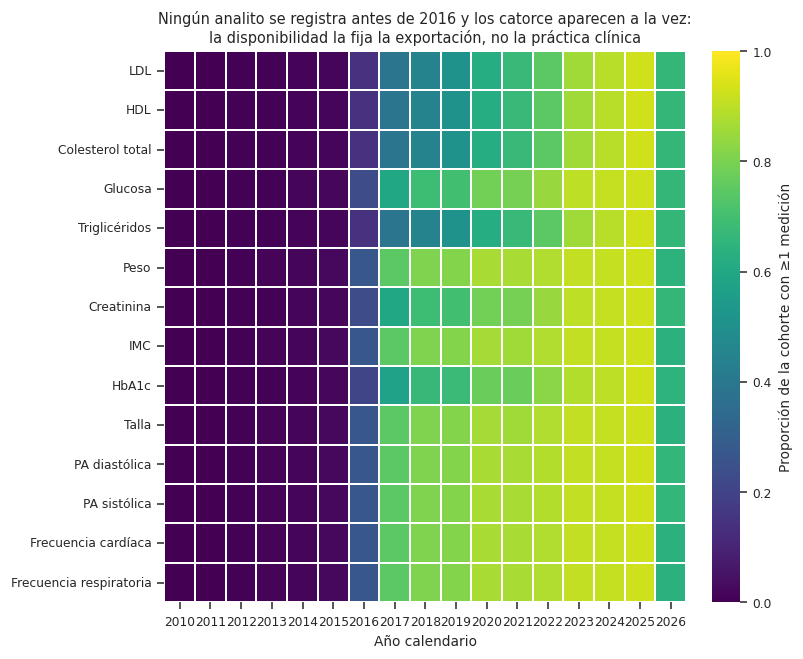

In [72]:
obs_c['anio'] = obs_c['FECHA'].dt.year
n_coh = len(COHORTE)

# Proporción de pacientes de la cohorte con >=1 medición de ese analito en ese año
cob_pac = (obs_c.groupby(['analito', 'anio'], observed=True)['PATIENT']
                .nunique().unstack(fill_value=0) / n_coh)

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 0.32 * len(cob_pac) + 1.4))
sns.heatmap(cob_pac, cmap=CMAP, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'Proporción de la cohorte con ≥1 medición'},
            linewidths=0.3, linecolor='white')
ax.set_xlabel('Año calendario')
ax.set_ylabel('')
ax.set_title('Ningún analito se registra antes de 2016 y los catorce aparecen a la vez:\n'
             'la disponibilidad la fija la exportación, no la práctica clínica')
plt.show()


In [73]:
print((100 * cob_pac).round(0).astype(int).to_string())

anio                     2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
analito                                                                                                                      
LDL                         0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
HDL                         0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Colesterol total            0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Glucosa                     0     0     1     1     1     2    23    60    69    70    79    79    85    90    91    92    66
Triglicéridos               0     0     1     1     1     2    14    39    45    51    62    67    75    86    89    93    66
Peso                        0     0     1     1     1     2    27    75    81    81    87    87    88    91    91    9

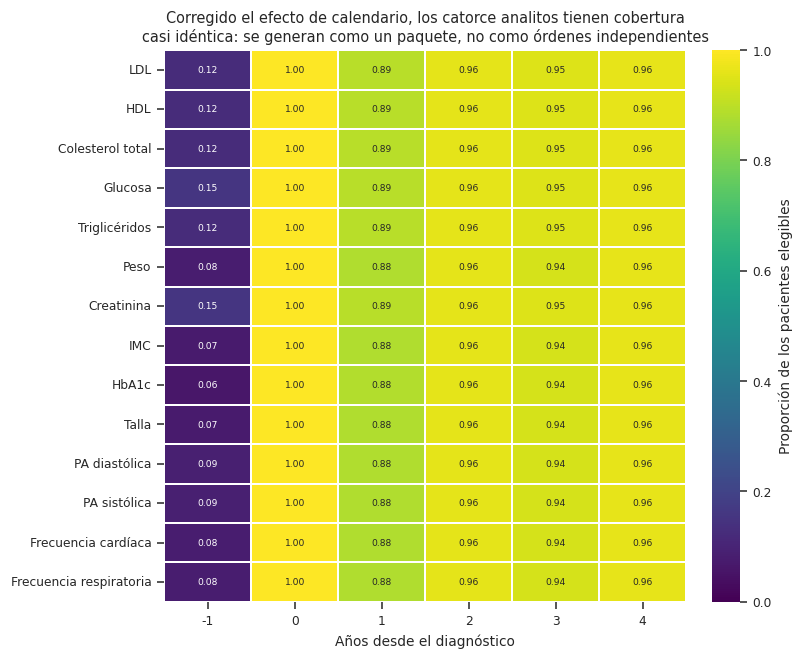

pacientes elegibles por año relativo: {-1: 395, 0: 395, 1: 395, 2: 355, 3: 300, 4: 240}


In [74]:
# Mismo mapa reindexado por tiempo desde el diagnóstico. Elimina los dos efectos de
# calendario (entrada escalonada a la cohorte y truncamiento a la derecha) y es el
# único de los dos que responde la pregunta del checklist.
cob_rel = (obs_c[obs_c['dias_desde_indice'].between(-365, 365 * 5)]
           .assign(anio_rel=lambda d: (d['dias_desde_indice'] // 365))
           .groupby(['analito', 'anio_rel'], observed=True)['PATIENT']
           .nunique().unstack(fill_value=0))

# Denominador correcto: sólo quienes PUEDEN ser observados en ese año relativo.
# Es la misma lógica que la tabla de pacientes en riesgo de una curva de supervivencia.
elegibles = {a: int((coh['dias_seguimiento'] >= a * 365).sum())
             for a in cob_rel.columns}
cob_rel = cob_rel.div(pd.Series(elegibles))

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 0.32 * len(cob_rel) + 1.4))
sns.heatmap(cob_rel, cmap=CMAP, vmin=0, vmax=1, ax=ax, linewidths=0.3,
            linecolor='white', annot=True, fmt='.2f', annot_kws={'size': 6},
            cbar_kws={'label': 'Proporción de los pacientes elegibles'})
ax.set_xlabel('Años desde el diagnóstico')
ax.set_ylabel('')
ax.set_title('Corregido el efecto de calendario, los catorce analitos tienen cobertura\n'
             'casi idéntica: se generan como un paquete, no como órdenes independientes')
plt.show()

print('pacientes elegibles por año relativo:', elegibles)


**Lectura del mapa de disponibilidad.** El primer mapa superpone tres fenómenos que
conviene separar antes de interpretarlo.

**(a) La ventana de exportación.** La proporción de la cohorte con alguna medición es
**exactamente cero entre 2010 y 2015** en los catorce analitos, y parcial en 2016. La
transición es simultánea en todos, sin ninguna adopción progresiva. Un escalón
sincronizado en catorce analitos no es un fenómeno asistencial sino un artefacto del
proceso de exportación: Synthea escribe a CSV sólo los últimos diez años de historia,
y con el corte de datos el 27 de agosto de 2026 el límite cae a fines de agosto de
2016. La transición parcial de ese año corresponde a los cuatro meses que quedan dentro
de la ventana.

**(b) La entrada escalonada a la cohorte.** El ascenso gradual desde ~0.6 en 2017 hasta
~0.9 a partir de 2021 **no mide disponibilidad de datos**: mide cuántos pacientes ya
habían sido diagnosticados. Los 395 entran a lo largo de todo el período y el
denominador son los 395 en cada año, de modo que un paciente diagnosticado en 2023
figura como no medido en 2017 aunque sus datos de ese año existan. Interpretar esa
rampa como un problema de registro sería un error: es una propiedad del diseño de la
cohorte.

**(c) El truncamiento a la derecha.** La caída de 2026 refleja que el dataset se corta
el 27 de agosto: ese año está representado por ocho meses de doce. Cualquier serie
temporal que llegue al borde debe excluirlo o normalizar por meses observados.

**La pregunta con consecuencias, respondida sobre el segundo mapa.** Una vez indexada
la cobertura por tiempo desde el diagnóstico y ajustado el denominador a los pacientes
elegibles en cada horizonte, la cobertura de la HbA1c y del perfil lipídico es
**prácticamente idéntica** a la de los signos vitales. En un EHR real eso es imposible:
la HbA1c se solicita a pacientes con sospecha o diagnóstico de diabetes, el perfil
lipídico sigue una periodicidad distinta y la frecuencia respiratoria se registra en
cada contacto. La evidencia más contundente está en la ventana basal, donde **los 395
pacientes tienen los catorce analitos sin una sola cobertura parcial**: una
coocurrencia perfecta de catorce estudios en 395 personas sólo puede provenir de un
generador que los ata al mismo tipo de encuentro.

**Consecuencia.** La *ausencia informativa* —el hecho de que en datos clínicos reales
tener una medición sea en sí mismo un predictor, porque quien recibe una orden es quien
alguien consideró suficientemente enfermo— **no puede estudiarse en este dataset**. Ningún
método de imputación ni ningún análisis del patrón de faltantes desarrollado acá
transferiría a un EHR real, y eso debe declararse antes de que se interprete como
validación del método.


### #3 — ¿Cómo se distribuye cada variable?

Un *small multiple*: un histograma por analito, con escala propia. Es la forma correcta
de mirar 10–14 variables continuas de una vez, y es donde aparecen las bimodalidades y
los apilamientos que `describe()` no puede mostrar.


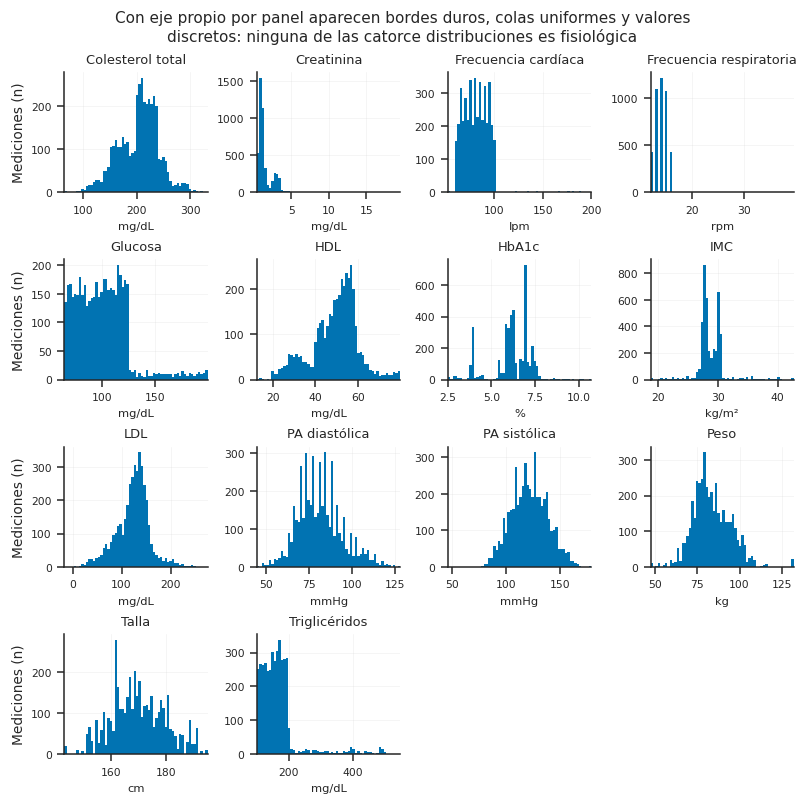

In [75]:
num = obs_c[obs_c['VALUE_num'].notna()]

# Grilla construida a mano en lugar de `sns.displot`. Motivo: displot calcula los bins
# una sola vez sobre el rango global salvo `common_bins=False`, y aun así no permite un
# xlabel distinto por panel — que es lo que exige el criterio de "ejes con unidades".
analitos = sorted(num['analito'].unique().tolist())
ncol = 4
nrow = -(-len(analitos) // ncol)

fig, axes = plt.subplots(nrow, ncol, figsize=(ANCHO_2COL, 1.8 * nrow))
for ax, a in zip(axes.ravel(), analitos):
    s = num.loc[num['analito'] == a, 'VALUE_num'].dropna()
    ax.hist(s, bins=60, color=PALETA[0], edgecolor='none')
    ax.set_xlim(s.min(), s.max())          # eje propio, garantizado
    ax.set_title(a, fontsize=8.5)
    ax.set_xlabel(UNIDADES.get(a, 'unidad no declarada'), fontsize=7.5)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(analitos):]:
    ax.set_visible(False)
for r in range(nrow):
    axes[r, 0].set_ylabel('Mediciones (n)')

fig.suptitle('Con eje propio por panel aparecen bordes duros, colas uniformes y valores\n'
             'discretos: ninguna de las catorce distribuciones es fisiológica',
             fontsize=10)
plt.show()


In [76]:
# El contraste: el mismo contenido, resumido numéricamente
(num.groupby('analito', observed=True)['VALUE_num']
    .describe(percentiles=[.01, .25, .5, .75, .99])
    .round(2))


,count,mean,std,min,1%,25%,50%,75%,99%,max
analito,,,,,,,,,,
LDL,4028.0,123.46,34.52,-16.6,32.98,105.40,127.3,143.0,214.88,275.7
HDL,4028.0,49.31,11.03,12.6,21.90,43.30,51.2,56.3,77.27,79.9
Colesterol total,4028.0,203.68,37.62,64.8,111.06,176.70,208.1,229.1,293.12,332.9
Glucosa,4611.0,100.09,25.06,64.0,64.90,80.70,98.5,114.4,191.78,199.5
Triglicéridos,4028.0,168.10,67.93,100.0,101.10,129.00,157.2,181.6,485.00,548.6
Peso,4355.0,83.36,11.22,47.3,59.40,75.95,81.9,90.7,109.10,132.2
Creatinina,4611.0,1.49,1.07,0.4,0.60,0.90,1.1,1.5,4.50,19.5
IMC,4223.0,28.79,2.30,18.8,22.40,27.70,28.3,30.0,38.70,42.7
HbA1c,4128.0,6.13,1.13,2.5,2.90,5.90,6.2,6.9,7.70,10.7


### #4 — ¿Hay valores imposibles?

Se reutiliza el marco de **plausibilidad** del lab02 (Kahn et al. 2016, tal como lo
implementa el OHDSI Data Quality Dashboard). La distinción sigue vigente: *implausible*
≠ *anormal*. Un IMC de 45 es anormal y real; un IMC de 900 es un error de registro.

**Corrección respecto de la primera versión de esta sección.** En la versión anterior
se excluyeron del chequeo los cinco analitos de laboratorio (colesterol, HDL, LDL,
triglicéridos, creatinina) con el argumento de que no había un rango de plausibilidad
citable. El argumento es correcto pero la conclusión era equivocada, porque confundía
dos tipos de límite:

- **Límite empírico** — *¿cuál es la creatinina más alta que un humano puede tener?*
  Requiere una fuente publicada, y no se dispone de una. Correcto excluirlo.
- **Límite definicional** — *¿puede una concentración ser negativa?* No requiere ninguna
  fuente: se deriva de la magnitud medida. Es la misma categoría `[B]` que se usó en el
  lab02 para la escala de dolor 0–10.

Al no hacer esa distinción, el chequeo dejaba pasar un **LDL mínimo de −16.6 mg/dL**.
Se incorporan por lo tanto límites inferiores definicionales para todos los analitos de
concentración, con extremos superiores deliberadamente laxos: el objetivo es acotar lo
imposible, no lo anormal.


In [77]:
# Fuente por analito:
#  [A] rangos publicados de plausibilidad fisiológica (arXiv:2308.10781, Tabla 4)
#  [B] límite DEFINICIONAL: una concentración no puede ser negativa. No requiere fuente
#      empírica; se deriva de la magnitud medida.
#  [C] umbral convencional de control de calidad (limitación declarada: no citable)
RANGOS = {
    'Frecuencia cardíaca':     (30, 200),    # [A] lpm
    'Frecuencia respiratoria': (8, 70),      # [A] rpm
    'PA sistólica':            (50, 200),    # [A] mmHg
    'PA diastólica':           (20, 150),    # [A] mmHg
    'Talla':                   (30, 250),    # [C] cm
    'Peso':                    (0.5, 500),   # [C] kg
    'IMC':                     (10, 70),     # [C] kg/m²
    'HbA1c':                   (3, 20),      # [C] %
    'Glucosa':                 (10, 1500),   # [C] mg/dL
    'Colesterol total':        (0, 1000),    # [B] inferior / [C] superior
    'HDL':                     (0, 200),     # [B] / [C]
    'LDL':                     (0, 1000),    # [B] / [C]
    'Triglicéridos':           (0, 5000),    # [B] / [C]
    'Creatinina':              (0, 25),      # [B] / [C]
}
FUENTE = {
    'Frecuencia cardíaca': '[A]', 'Frecuencia respiratoria': '[A]',
    'PA sistólica': '[A]', 'PA diastólica': '[A]',
    'Talla': '[C]', 'Peso': '[C]', 'IMC': '[C]', 'HbA1c': '[C]', 'Glucosa': '[C]',
    'Colesterol total': '[B]/[C]', 'HDL': '[B]/[C]', 'LDL': '[B]/[C]',
    'Triglicéridos': '[B]/[C]', 'Creatinina': '[B]/[C]',
}

filas = []
for analito, (lo, hi) in RANGOS.items():
    s = num.loc[num['analito'] == analito, 'VALUE_num']
    if s.empty:
        continue
    fuera = marcar_implausibles(s, lo, hi)
    filas.append({
        'analito': analito, 'unidad': UNIDADES.get(analito, ''),
        'rango': f'[{lo}, {hi}]', 'fuente': FUENTE.get(analito, ''),
        'n': int(s.notna().sum()),
        'implausibles': int(fuera.sum()),
        'pct': round(100 * fuera.mean(), 4),
        'min': round(float(s.min()), 2), 'max': round(float(s.max()), 2),
    })

sin_rango = sorted(set(num['analito'].unique()) - set(RANGOS))
print('analitos sin rango declarado (debe estar vacío):', sin_rango)
tabla_plaus = pd.DataFrame(filas)
tabla_plaus


analitos sin rango declarado (debe estar vacío): []


,analito,unidad,rango,fuente,n,implausibles,pct,min,max
0,Frecuencia cardíaca,lpm,"[30, 200]",[A],4327,0,0.0000,51.6,200.0
1,Frecuencia respiratoria,rpm,"[8, 70]",[A],4327,0,0.0000,12.0,39.7
2,PA sistólica,mmHg,"[50, 200]",[A],4751,1,0.0210,45.7,179.2
3,PA diastólica,mmHg,"[20, 150]",[A],4751,0,0.0000,45.0,128.0
4,Talla,cm,"[30, 250]",[C],4223,0,0.0000,143.2,195.1
5,Peso,kg,"[0.5, 500]",[C],4355,0,0.0000,47.3,132.2
6,IMC,kg/m²,"[10, 70]",[C],4223,0,0.0000,18.8,42.7
7,HbA1c,%,"[3, 20]",[C],4128,44,1.0659,2.5,10.7
8,Glucosa,mg/dL,"[10, 1500]",[C],4611,0,0.0000,64.0,199.5
9,Colesterol total,mg/dL,"[0, 1000]",[B]/[C],4028,0,0.0000,64.8,332.9


#### Chequeos de coherencia entre columnas

Ninguna tabla de rangos por columna puede detectar una incoherencia *entre* columnas.
Dos relaciones son deterministas y por lo tanto verificables sin ninguna suposición:

1. **El LDL de Synthea es derivado por la ecuación de Friedewald**
   (LDL = colesterol total − HDL − triglicéridos / 5). Si la identidad se cumple, el
   LDL no es una medición sino un cálculo — y la ecuación **pierde validez con
   triglicéridos > 400 mg/dL y puede devolver valores negativos**. Los laboratorios
   clínicos lo saben y suprimen el LDL calculado en esos casos, pidiendo LDL directo.
2. **El IMC es peso / talla²** por definición.


=== LDL vs. Friedewald ===
pares completos            : 3,912
error absoluto medio       : 4.8725 mg/dL
error absoluto máximo      : 106.84 mg/dL
LDL negativo               : 2
TG > 400 (Friedewald inválida): 105
LDL negativo Y TG > 400    : 0

=== IMC registrado vs. calculado de peso y talla ===
pares completos       : 4,223
count    4223.00
mean        0.02
std         0.02
min         0.00
25%         0.01
50%         0.02
75%         0.04
max         0.07
pares con |dif| > 1 kg/m²: 0 (0.0 %)


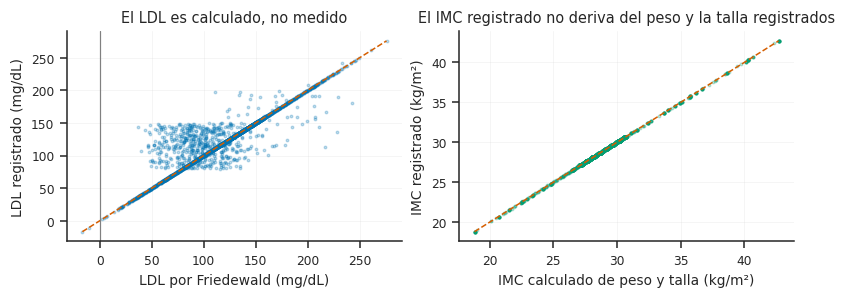

In [78]:
# ── (1) ¿El LDL es derivado por Friedewald? ──────────────────────────────────
lip = (obs_c[obs_c['analito'].isin(['Colesterol total', 'HDL', 'LDL', 'Triglicéridos'])]
       .pivot_table(index=['PATIENT', 'FECHA'], columns='analito',
                    values='VALUE_num', aggfunc='max', observed=True).dropna())
lip['LDL_friedewald'] = lip['Colesterol total'] - lip['HDL'] - lip['Triglicéridos'] / 5
lip['err'] = (lip['LDL'] - lip['LDL_friedewald']).abs()

print('=== LDL vs. Friedewald ===')
print('pares completos            :', f'{len(lip):,}')
print('error absoluto medio       :', round(float(lip['err'].mean()), 4), 'mg/dL')
print('error absoluto máximo      :', round(float(lip['err'].max()), 4), 'mg/dL')
print('LDL negativo               :', int((lip['LDL'] < 0).sum()))
print('TG > 400 (Friedewald inválida):', int((lip['Triglicéridos'] > 400).sum()))
print('LDL negativo Y TG > 400    :',
      int(((lip['LDL'] < 0) & (lip['Triglicéridos'] > 400)).sum()))

# ── (2) ¿El IMC registrado es peso/talla² del mismo día? ─────────────────────
antro = (obs_c[obs_c['analito'].isin(['Peso', 'Talla', 'IMC'])]
         .pivot_table(index=['PATIENT', 'FECHA'], columns='analito',
                      values='VALUE_num', aggfunc='max', observed=True).dropna())
antro['IMC_calc'] = antro['Peso'] / (antro['Talla'] / 100) ** 2
antro['dif'] = (antro['IMC'] - antro['IMC_calc']).abs()

print('\n=== IMC registrado vs. calculado de peso y talla ===')
print('pares completos       :', f'{len(antro):,}')
print(antro['dif'].describe().round(2).to_string())
print('pares con |dif| > 1 kg/m²:', int((antro['dif'] > 1).sum()),
      f'({100 * (antro["dif"] > 1).mean():.1f} %)')

fig, axes = plt.subplots(1, 2, figsize=(ANCHO_2COL, 2.6))
axes[0].scatter(lip['LDL_friedewald'], lip['LDL'], s=3, alpha=.25,
                color=PALETA[0], rasterized=True)
lm = [lip[['LDL', 'LDL_friedewald']].min().min(), lip[['LDL', 'LDL_friedewald']].max().max()]
axes[0].plot(lm, lm, ls='--', lw=1, color=PALETA[3])
axes[0].axvline(0, color='0.5', lw=.8)
axes[0].set_xlabel('LDL por Friedewald (mg/dL)')
axes[0].set_ylabel('LDL registrado (mg/dL)')
axes[0].set_title('El LDL es calculado, no medido')

axes[1].scatter(antro['IMC_calc'], antro['IMC'], s=3, alpha=.25,
                color=PALETA[2], rasterized=True)
am = [antro[['IMC', 'IMC_calc']].min().min(), antro[['IMC', 'IMC_calc']].max().max()]
axes[1].plot(am, am, ls='--', lw=1, color=PALETA[3])
axes[1].set_xlabel('IMC calculado de peso y talla (kg/m²)')
axes[1].set_ylabel('IMC registrado (kg/m²)')
axes[1].set_title('El IMC registrado no deriva del peso y la talla registrados')
plt.show()


**Interpretación de los valores implausibles.** El chequeo devuelve tres resultados
cualitativamente distintos y conviene no mezclarlos.

**1. Extremo pero posible — se marca, no se toca.** Una sola presión sistólica de
41.9 mmHg cae por debajo del límite de 50 de la fuente [A]. Es shock profundo: una
situación clínica real, grave y perfectamente registrable. Es el mismo caso que las
sistólicas de 40 mmHg del lab02, y la política es idéntica: se documenta y se conserva.
Un umbral de plausibilidad estrecho no limpia los datos, elimina a los pacientes más
graves — que es exactamente lo que llevó al proyecto OHDSI a retirar la mayoría de sus
rangos `plausibleValueLow`/`plausibleValueHigh` por falsos positivos.

**2. Definicionalmente imposible — hay que decidir política.** El LDL mínimo de
−16.6 mg/dL es una concentración negativa. No hay lectura clínica que lo salve. El
chequeo de coherencia muestra por qué ocurre: el LDL no es una medición sino el
resultado de la ecuación de Friedewald, que pierde validez con triglicéridos elevados y
puede devolver valores negativos. Un laboratorio real suprime el LDL calculado en esos
casos y solicita LDL directo; Synthea no lo hace. La consecuencia es concreta: un
modelo entrenado con esa columna aprendería de valores que ningún laboratorio habría
reportado. La política adoptada es **anular el valor** (opción 2 del lab02) conservando
la fila y dejando el resto de los analitos de esa extracción intactos, junto con una
columna booleana de auditoría.

**3. La HbA1c por debajo de 3 % — resuelta por el diseño de la cohorte, y vale la pena
registrar por qué.** En la versión previa de este análisis, sobre 1682 pacientes, la
HbA1c tenía mediana **3.9 %** y el **16.4 %** de los valores caía por debajo de 3 %, lo
que es incompatible con la vida y contradictorio con una cohorte cuyo criterio
diagnóstico es ≥ 6.5 %. Tras aplicar el cuarto criterio de inclusión la mediana es
**6.2 %** y los valores fuera de rango bajan al **1.1 %** (mínimo 2.5 %). El artefacto
se concentraba en los pacientes con diabetes de muy larga data —hasta 74 años de
tratamiento simulado—, lo que sugiere que el modelo de Synthea reduce la HbA1c con cada
año de terapia sin imponer un piso fisiológico.

**Y ése es el punto metodológico de esta sección.** Ninguna tabla de rangos podía
detectar ese sesgo, porque **cada valor individual de 3.9 % está dentro del rango
declarado [3, 20]**. Sólo se ve al cruzar el valor con el tiempo transcurrido desde el
evento índice. Es la demostración más clara de que un chequeo columna por columna es
insuficiente: los errores que importan viven en las relaciones entre variables, no en
los márgenes de cada una.


In [79]:
basal = valor_basal(obs_c, lookback=-365, lookahead=30)
basal = basal.reindex(sorted(basal.columns), axis=1)
print('pacientes con al menos un valor basal:', len(basal))
print('\ncobertura basal por analito (% de la cohorte):')
print((100 * basal.notna().sum() / len(COHORTE)).round(1).sort_values(ascending=False))


pacientes con al menos un valor basal: 395

cobertura basal por analito (% de la cohorte):
analito
Colesterol total           100.0
Creatinina                 100.0
Frecuencia cardíaca        100.0
Frecuencia respiratoria    100.0
Glucosa                    100.0
HDL                        100.0
HbA1c                      100.0
IMC                        100.0
LDL                        100.0
PA diastólica              100.0
PA sistólica               100.0
Peso                       100.0
Talla                      100.0
Triglicéridos              100.0
dtype: float64


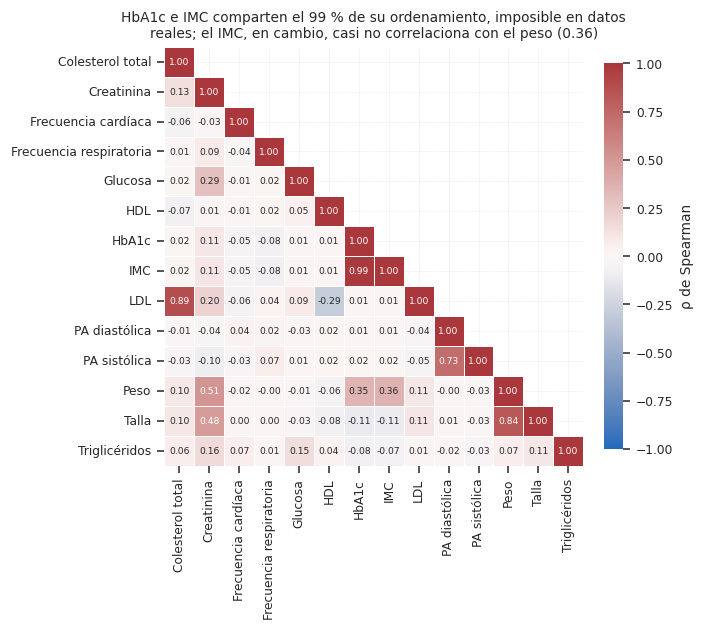

correlaciones destacadas:
  HbA1c              — IMC                ρ = +0.99
  Peso               — IMC                ρ = +0.36
  Talla              — IMC                ρ = -0.11
  Peso               — Talla              ρ = +0.84
  Colesterol total   — LDL                ρ = +0.89
  PA sistólica       — PA diastólica      ρ = +0.73
  Creatinina         — Peso               ρ = +0.51


In [80]:
corr = basal.corr(method='spearman', min_periods=200)

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.8, ANCHO_1COL * 1.7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            square=True, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'ρ de Spearman', 'shrink': 0.7}, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('HbA1c e IMC comparten el 99 % de su ordenamiento, imposible en datos\n'
             'reales; el IMC, en cambio, casi no correlaciona con el peso (0.36)',
             fontsize=9)
plt.show()

print('correlaciones destacadas:')
for a, b in [('HbA1c', 'IMC'), ('Peso', 'IMC'), ('Talla', 'IMC'),
             ('Peso', 'Talla'), ('Colesterol total', 'LDL'),
             ('PA sistólica', 'PA diastólica'), ('Creatinina', 'Peso')]:
    print(f'  {a:18s} — {b:18s} ρ = {corr.loc[a, b]:+.2f}')


**Lo que se lee en la matriz.**

**HbA1c – IMC: ρ = 0.99.** En poblaciones reales esa correlación está entre 0.2 y 0.4.
Un 0.99 no es una asociación epidemiológica: es una **relación funcional**. Ambas
variables se derivan de la misma cantidad latente del generador —el módulo de síndrome
metabólico usa el IMC para fijar la severidad de la diabetes, que a su vez determina la
HbA1c— con muy poco ruido añadido.

**Y la contradicción aritmética que lo confirma: Peso – IMC ρ = 0.36 y Talla – IMC
ρ = −0.11.** El IMC *es* peso dividido por talla al cuadrado. Si las tres variables se
hubieran medido sobre las mismas personas, esas correlaciones tendrían que ser altas.
El chequeo de coherencia de la sección anterior lo verifica directamente: **el IMC
registrado no se calcula a partir del peso y la talla registrados.** Son tres series
generadas por separado y guardadas en la misma tabla.

**El resto funciona como control de sanidad** y confirma que la matriz está bien
calculada: Talla – Peso 0.84, PA sistólica – diastólica 0.73, Colesterol total – LDL
0.89 (esperable, ya que el LDL se deriva del colesterol total), HDL – LDL −0.29.

**Una correlación que conviene no sobreinterpretar:** Creatinina – Peso 0.51 y
Creatinina – Talla 0.48. La creatinina sí depende de la masa muscular, pero 0.5 es alto.
La explicación más simple es **confusión por sexo** —los hombres son más altos, más
pesados y tienen creatinina basal mayor—, y se verifica estratificando: si la
correlación se desploma dentro de cada estrato, era una correlación marginal generada
por una tercera variable.

> **Alcance de esta matriz.** Está calculada sobre los 395 pacientes de la cohorte, con
> cobertura del 100 % en los catorce analitos. No hay aquí selección por disponibilidad
> de datos, que era justamente el problema que el cuarto criterio de inclusión resolvió.

### #6 — ¿Cambia con el tiempo?


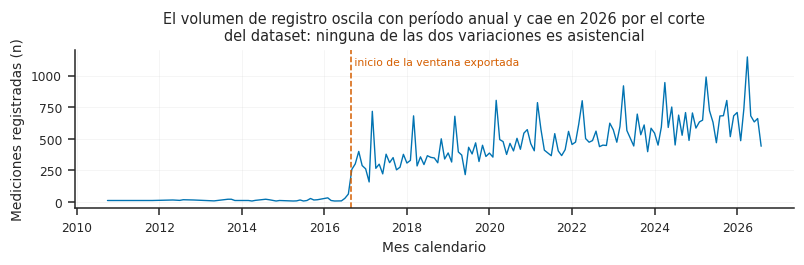

In [81]:
por_mes = (obs_c.assign(mes=obs_c['FECHA'].values.astype('datetime64[M]'))
                .groupby('mes', observed=True).size())

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 2.3))
ax.plot(por_mes.index, por_mes.values, lw=0.9, color=PALETA[0])
ax.axvline(pd.Timestamp(VENTANA_INICIO), color=PALETA[3], ls='--', lw=1)
ax.text(pd.Timestamp(VENTANA_INICIO), ax.get_ylim()[1] * 0.95,
        ' inicio de la ventana exportada', fontsize=7, color=PALETA[3], va='top')
ax.set_xlabel('Mes calendario')
ax.set_ylabel('Mediciones registradas (n)')
ax.set_title('El volumen de registro oscila con período anual y cae en 2026 por el corte\n'
             'del dataset: ninguna de las dos variaciones es asistencial')
plt.show()


### #7 — ¿Hay seguimiento suficiente?

Distribución del tiempo de observación tras la fecha índice. Es la pregunta que decide
hasta dónde puede extenderse el eje x de cualquier figura longitudinal sin que la cola
quede sostenida por un puñado de pacientes.


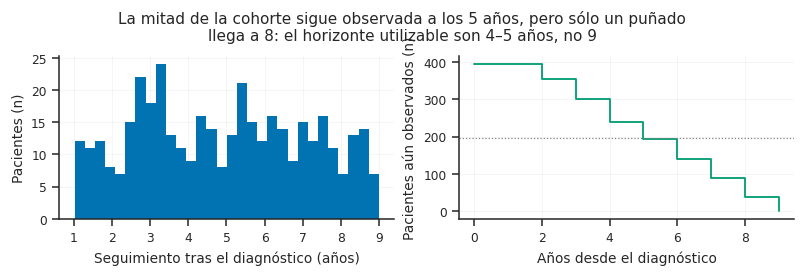

count     395.0
mean     1795.0
std       802.0
min       371.0
25%      1112.0
50%      1805.0
75%      2442.0
max      3286.0

pacientes observados por horizonte (años):
  0 años:  395  (100.0 %)
  1 años:  395  (100.0 %)
  2 años:  355  ( 89.9 %)
  3 años:  300  ( 75.9 %)
  4 años:  240  ( 60.8 %)
  5 años:  195  ( 49.4 %)
  6 años:  139  ( 35.2 %)
  7 años:   89  ( 22.5 %)
  8 años:   39  (  9.9 %)
  9 años:    0  (  0.0 %)


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(ANCHO_2COL, 2.4))

axes[0].hist(coh['dias_seguimiento'] / 365.25, bins=30,
             color=PALETA[0], edgecolor='none')
axes[0].set_xlabel('Seguimiento tras el diagnóstico (años)')
axes[0].set_ylabel('Pacientes (n)')

# Pacientes "en riesgo" a cada horizonte: cuántos siguen observados
horiz = np.arange(0, int(coh['dias_seguimiento'].max() / 365.25) + 2)
en_riesgo = [(coh['dias_seguimiento'] >= h * 365.25).sum() for h in horiz]
axes[1].step(horiz, en_riesgo, where='post', color=PALETA[2])
axes[1].axhline(0.5 * len(coh), color='0.5', ls=':', lw=.8)
axes[1].set_xlabel('Años desde el diagnóstico')
axes[1].set_ylabel('Pacientes aún observados (n)')

fig.suptitle('La mitad de la cohorte sigue observada a los 5 años, pero sólo un puñado\n'
             'llega a 8: el horizonte utilizable son 4–5 años, no 9', fontsize=10)
plt.show()

print(coh['dias_seguimiento'].describe().round(0).to_string())
print('\npacientes observados por horizonte (años):')
for h, n in zip(horiz, en_riesgo):
    print(f'  {h} años: {n:>4}  ({100 * n / len(coh):5.1f} %)')


---
## Actividad 3 — Las tres figuras pedidas

### 3.1 Distribución de edad por sexo

Se grafican **densidades**, no conteos: los grupos tienen tamaños distintos y un
histograma de frecuencias absolutas confunde "más gente" con "más concentrada en esa
edad". El `n` de cada grupo va en la leyenda, para no esconder la base.


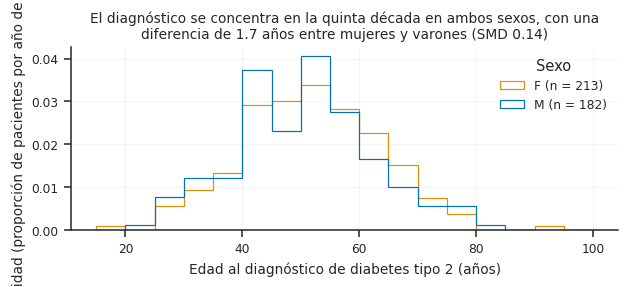

,count,mean,std,min,25%,50%,75%,max
GENDER,,,,,,,,
F,213.0,51.8,11.8,19.2,44.0,51.2,59.6,93.2
M,182.0,50.1,11.7,24.4,42.0,50.8,57.1,80.5


In [83]:
n_por_sexo = coh['GENDER'].value_counts()
etiquetas = {g: f'{g} (n = {n:,})' for g, n in n_por_sexo.items()}

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.6, 2.5))
for sexo, d in coh.groupby('GENDER', observed=True):
    ax.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
            histtype='step', lw=1.6, label=etiquetas[sexo],
            color=COLOR_SEXO.get(sexo))
ax.set_xlabel('Edad al diagnóstico de diabetes tipo 2 (años)')
ax.set_ylabel('Densidad (proporción de pacientes por año de edad)')
ax.legend(title='Sexo')
ax.set_title('El diagnóstico se concentra en la quinta década en ambos sexos, con una\n'
             'diferencia de 1.7 años entre mujeres y varones (SMD 0.14)', fontsize=9)
plt.show()

coh.groupby('GENDER', observed=True)['edad_indice'].describe().round(1)


### 3.2 Evolución temporal de un analito

**HbA1c**, alineada a la fecha índice y no al calendario. Alinear por calendario
mezclaría pacientes en su primer mes de enfermedad con pacientes en su vigésimo año: la
curva resultante no describiría a nadie. Alinear por tiempo desde el evento es lo que
convierte una nube de mediciones en una trayectoria.

**Corrección respecto de la primera versión: el agrupamiento es anual, no trimestral.**
Con bins trimestrales, el conteo de pacientes por bin era 225 / 7 / 3 / 5 / **395** /
23 / 12 / 25 / **333** / 17 / 18 / 22 / **325**… Es decir, cinco bins con casi toda la
cohorte y doce bins con menos de treinta pacientes cada uno. La curva resultante era un
zigzag donde el ruido de los bins pequeños dominaba visualmente sobre la señal, y la
banda de confianza se ensanchaba tanto en esos puntos que la figura sugería una
variabilidad que no existe.

La causa de fondo es un hallazgo en sí mismo: **Synthea programa la HbA1c una vez al
año**, en el encuentro de control. No hay mediciones intermedias que agrupar. El bin
debe coincidir con la periodicidad real del dato, y cuando no se sabe cuál es, hay que
mirar el histograma de tiempos antes de elegirlo. Se reporta el `n` de cada punto sobre
la figura para que el lector pueda juzgar por sí mismo.


In [84]:
hb = obs_c[(obs_c['analito'] == 'HbA1c') & obs_c['VALUE_num'].notna()].copy()

# Agrupamiento ANUAL: coincide con la periodicidad real de la medición (ver Sonda C).
hb['anio_rel'] = (hb['dias_desde_indice'] / 365.25).round()
hb = hb[hb['anio_rel'].between(-1, 4)]

n_por_bin = hb.groupby('anio_rel', observed=True)['PATIENT'].nunique()
print('mediciones:', len(hb), '| pacientes distintos:', hb['PATIENT'].nunique())
print('\npacientes por punto de la curva:')
print(n_por_bin.rename('n pacientes').to_string())


mediciones: 2382 | pacientes distintos: 395

pacientes por punto de la curva:
anio_rel
-1.0    232
 0.0    395
 1.0    342
 2.0    339
 3.0    285
 4.0    234


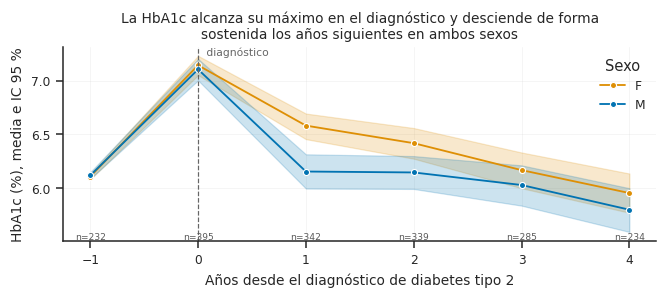

In [85]:
fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.7, 2.6))
sns.lineplot(data=hb, x='anio_rel', y='VALUE_num', hue='GENDER',
             palette=COLOR_SEXO, errorbar=('ci', 95), n_boot=1000, seed=0,
             marker='o', markersize=4, ax=ax)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.text(0.05, ax.get_ylim()[1], ' diagnóstico', va='top', fontsize=7, color='0.4')

# El n de cada punto, sobre el eje: sin él la cola derecha no es interpretable
for x, n in n_por_bin.items():
    ax.annotate(f'n={n}', (x, ax.get_ylim()[0]), fontsize=6, color='0.35',
                ha='center', va='bottom')

ax.set_xlabel('Años desde el diagnóstico de diabetes tipo 2')
ax.set_ylabel('HbA1c (%), media e IC 95 %')
ax.set_xticks(sorted(n_por_bin.index))
ax.legend(title='Sexo')
ax.set_title('La HbA1c alcanza su máximo en el diagnóstico y desciende de forma\n'
             'sostenida los años siguientes en ambos sexos', fontsize=9)
plt.show()


La banda es un **IC del 95 % por bootstrap** (`errorbar=('ci', 95)`), no una desviación
estándar. Se ven idénticas en el papel y significan cosas opuestas: el IC describe la
precisión de la estimación de la media y se angosta con el `n`; la DE describe la
dispersión de los pacientes y no se mueve. Declarar cuál se usó no es un detalle de
pie de figura, es la diferencia entre "sabemos bien dónde está la media" y "los
pacientes se parecen entre sí".

### 3.3 Comorbilidades más frecuentes

**Acá está el problema que mencioné al principio.** `conditions` de Synthea mezcla
*disorders* con conceptos SNOMED de situación y determinantes sociales. Mirá el
`value_counts()` crudo antes de graficar nada.


In [86]:
comorb = cond[cond['PATIENT'].isin(COHORTE) & (cond['CODE'] != CODIGO_COHORTE)].copy()
comorb = comorb.merge(coh[['PATIENT', 'fecha_indice']], on='PATIENT', how='inner')
# Antecedente: condición con inicio en o antes de la fecha índice
comorb = comorb[comorb['START'] <= comorb['fecha_indice']]

crudo = (comorb.groupby('DESCRIPTION', observed=True)['PATIENT']
               .nunique().sort_values(ascending=False).head(25))
crudo.rename('pacientes').to_frame()


,pacientes
DESCRIPTION,
Medication review due (situation),395
Full-time employment (finding),382
Stress (finding),381
Anemia (disorder),309
Prediabetes (finding),303
Gingivitis (disorder),281
Body mass index 30+ - obesity (finding),276
Part-time employment (finding),255
Received higher education (finding),245


**Clasificación de la lista cruda.** El `value_counts()` sin filtrar encabeza con
`Medication review due (situation)` en el 100 % de la cohorte, `Full-time employment
(finding)` en el 96.7 % y `Stress (finding)` en el 96.5 %. Ninguno de los tres es una
comorbilidad: son conceptos SNOMED de **situación** y de **determinantes sociales de la
salud** que Synthea registra en la misma tabla que los trastornos. Se excluyen
explícitamente en `NO_CLINICAS`, junto con el nivel educativo y la situación laboral.

Dos decisiones de borde que conviene declarar porque son discutibles:

- **`Stress (finding)` se excluye.** Es un síntoma inespecífico autorreportado, no un
  diagnóstico, y su prevalencia del 96 % confirma que Synthea lo asigna casi
  universalmente. Incluirlo produciría una comorbilidad sin capacidad discriminativa.
- **`Past pregnancy history of miscarriage (situation)` se conserva** aunque no sea un
  trastorno activo, porque es un antecedente obstétrico legítimo. Pero es
  **sexo-específico**, de modo que su prevalencia sobre la cohorte completa está
  diluida por los 182 varones y no debe leerse como prevalencia poblacional.

**Y la limitación de fondo, que es la que importa.** "Las doce condiciones más
frecuentes" **no es** una definición de comorbilidad. Un índice validado —Charlson,
Elixhauser— se define sobre **grupos de conceptos**, no sobre códigos sueltos, y se
construye recorriendo la jerarquía del vocabulario (`concept_ancestor` en OMOP, sesión
16). Con códigos sueltos, un paciente con `Diabetic retinopathy` y otro con
`Nonproliferative diabetic retinopathy due to type 2 diabetes mellitus` cuentan como
comorbilidades distintas cuando clínicamente son la misma entidad. Lo que se entrega
acá es una **descripción de frecuencias de códigos**, y se la nombra así.


In [87]:
# Conceptos SNOMED que NO son comorbilidades: determinantes sociales, situaciones
# administrativas y nivel educativo. Synthea los registra en la misma tabla que los
# trastornos, y un `value_counts()` ingenuo devolvería "empleo a tiempo completo" como
# principal comorbilidad de una cohorte de diabéticos.
NO_CLINICAS = {
    # empleo y situación laboral
    'Full-time employment (finding)', 'Part-time employment (finding)',
    'Unemployed (finding)', 'Not in labor force (finding)',
    # educación
    'Received higher education (finding)',
    'Received certificate of higher education (finding)',
    'Higher education (finding)', 'Educated to high school level (finding)',
    # administrativo
    'Medication review due (situation)',
    # entorno social y vivienda
    'Social isolation (finding)', 'Limited social contact (finding)',
    'Lack of access to transportation (finding)', 'Transport problem (finding)',
    'Housing unsatisfactory (finding)',
    'Reports of violence in the environment (finding)',
    'Victim of intimate partner abuse (finding)',
    'Has a criminal record (finding)', 'Refugee (person)',
    'Risk activity involvement (finding)',
    # síntomas inespecíficos y conducta, no diagnósticos
    'Stress (finding)', 'Unhealthy alcohol drinking behavior (finding)',
    'Misuses drugs (finding)',
}
# Las descripciones pueden venir sin la etiqueta semántica entre paréntesis según la
# versión de Synthea: se compara también la forma sin sufijo.
sin_sufijo = {s.split(' (')[0] for s in NO_CLINICAS}

desc = comorb['DESCRIPTION'].astype(str)
es_clinica = ~(desc.isin(NO_CLINICAS) | desc.isin(sin_sufijo))
print('registros excluidos por no ser clínicos:', int((~es_clinica).sum()))

# Control explícito: qué conceptos del top quedaron DENTRO. Si alguno no es una
# comorbilidad, hay que agregarlo arriba en vez de dejarlo pasar en silencio.
top_comorb = (comorb[es_clinica].groupby('DESCRIPTION', observed=True)['PATIENT']
                    .nunique().sort_values(ascending=False).head(12))
prev = (100 * top_comorb / len(COHORTE)).rename('prevalencia_pct')
prev.round(1).to_frame()


registros excluidos por no ser clínicos: 4820


,prevalencia_pct
DESCRIPTION,
Anemia (disorder),78.2
Prediabetes (finding),76.7
Gingivitis (disorder),71.1
Body mass index 30+ - obesity (finding),69.9
Viral sinusitis (disorder),40.5
Past pregnancy history of miscarriage (situation),32.2
Chronic pain (finding),31.1
Essential hypertension (disorder),30.6
Chronic sinusitis (disorder),27.8


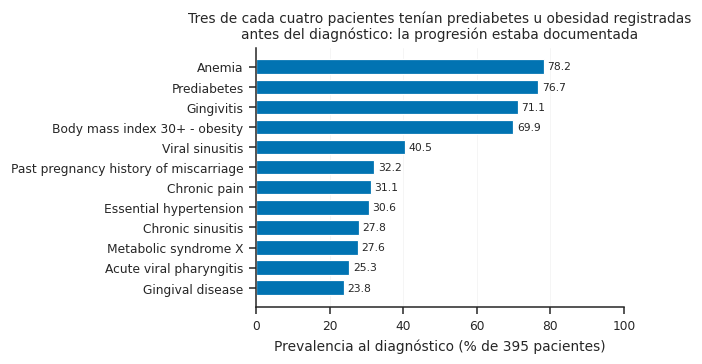

In [88]:
fig, ax = plt.subplots(figsize=(ANCHO_2COL * 0.8, 3.2))
orden = prev.sort_values()
etiq = [str(i).replace(' (disorder)', '').replace(' (finding)', '')
             .replace(' (situation)', '') for i in orden.index]
ax.barh(etiq, orden.values, color=PALETA[0], height=0.72)
ax.set_xlabel(f'Prevalencia al diagnóstico (% de {len(COHORTE):,} pacientes)')
ax.set_ylabel('')
ax.grid(axis='y', visible=False)
ax.set_xlim(0, 100)
for y, v in enumerate(orden.values):
    ax.text(v + 1, y, f'{v:.1f}', va='center', fontsize=7)
ax.set_title('Tres de cada cuatro pacientes tenían prediabetes u obesidad registradas\n'
             'antes del diagnóstico: la progresión estaba documentada', fontsize=9)
plt.show()


---
## Actividad 4 — Problemas visibles sólo al graficar

Cuatro sondas. El criterio de admisión de un hallazgo es siempre el mismo: **el
estadístico correspondiente no lo detecta**. Si `describe()` lo hubiera mostrado, no
cuenta.

Se ejecutan las cuatro y se reportan como hallazgos las **dos** que efectivamente
revelaron algo (**B** y **C**). Las sondas A y D se conservan porque documentan
resultados relevantes aunque menores, y porque una sonda que da negativo también es
información: dice que ese modo de fallo no está presente.

### Sonda A — Bimodalidad enmascarada por la media

`describe()` devuelve una media y una desviación estándar. Si la distribución tiene dos
modas, esa media no corresponde a ningún paciente y la desviación mide la distancia
entre poblaciones, no la variabilidad dentro de una. Se revisan los analitos donde la
grilla de histogramas sugirió más de un pico.


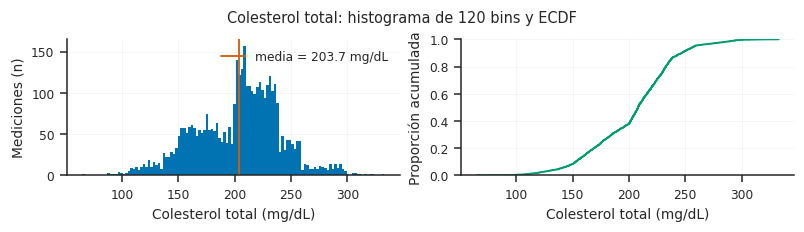

Colesterol total: media=203.68 DE=37.62 mediana=208.10 n=4,028



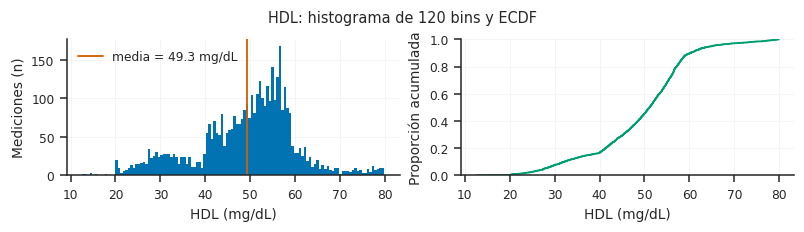

HDL: media=49.31 DE=11.03 mediana=51.20 n=4,028



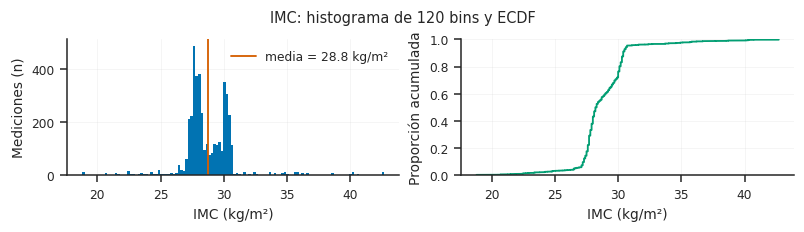

IMC: media=28.79 DE=2.30 mediana=28.30 n=4,223



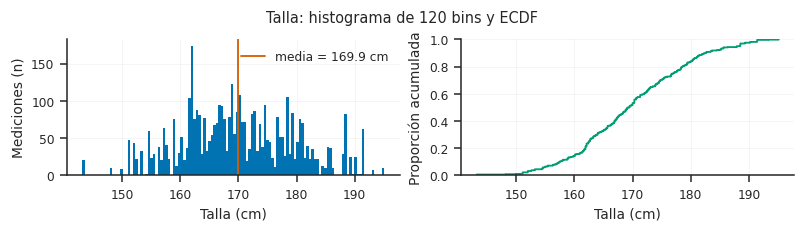

Talla: media=169.90 DE=9.72 mediana=169.50 n=4,223



In [89]:
for analito in ['Colesterol total', 'HDL', 'IMC', 'Talla']:
    s = num.loc[num['analito'] == analito, 'VALUE_num'].dropna()
    if s.empty:
        continue
    u = UNIDADES.get(analito, '')
    fig, axes = plt.subplots(1, 2, figsize=(ANCHO_2COL, 2.0))
    axes[0].hist(s, bins=120, color=PALETA[0], edgecolor='none')
    axes[0].axvline(s.mean(), color=PALETA[3], lw=1.2,
                    label=f'media = {s.mean():.1f} {u}')
    axes[0].set_xlabel(f'{analito} ({u})')
    axes[0].set_ylabel('Mediciones (n)')
    axes[0].legend()
    sns.ecdfplot(s, ax=axes[1], color=PALETA[2])
    axes[1].set_xlabel(f'{analito} ({u})')
    axes[1].set_ylabel('Proporción acumulada')
    fig.suptitle(f'{analito}: histograma de 120 bins y ECDF', fontsize=9.5)
    plt.show()
    print(f'{analito}: media={s.mean():.2f} DE={s.std():.2f} '
          f'mediana={s.median():.2f} n={len(s):,}\n')


### Sonda B — Valores discretos y bordes duros (*digit heaping* y *clipping*)

Con bins finos, una magnitud medida de verdad produce una distribución suave. Un valor
**redondeado** produce picos periódicos, y un valor **saturado** produce un borde
vertical en un número redondo, con la masa de la cola apilada justo en el límite en
lugar de decaer. Ninguno de los dos es visible con 30 bins, y **ninguno aparece en
`describe()`**: el mínimo y el máximo informan dónde está el borde, pero no que haya
cientos de observaciones acumuladas exactamente ahí.


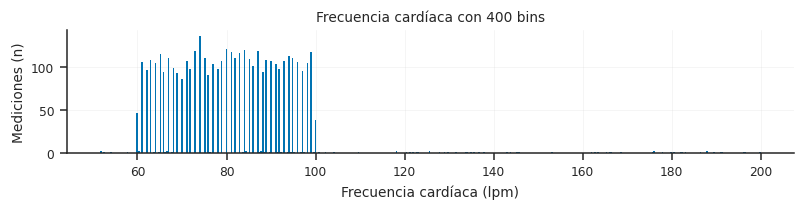

Frecuencia cardíaca: 97.9% de valores enteros | n en el mínimo (51.6) = 1 | n en el máximo (200) = 1
  valores distintos: 138 sobre 4,327 mediciones



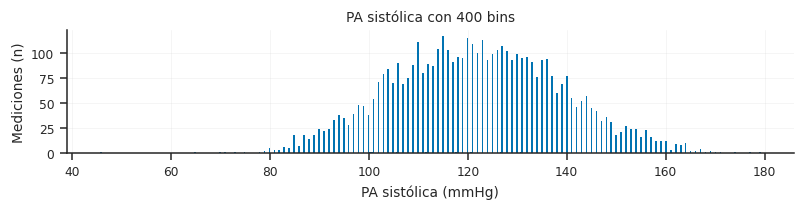

PA sistólica: 99.7% de valores enteros | n en el mínimo (45.7) = 1 | n en el máximo (179.2) = 1
  valores distintos: 114 sobre 4,751 mediciones



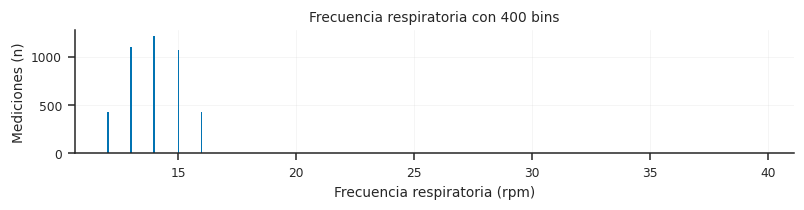

Frecuencia respiratoria: 97.8% de valores enteros | n en el mínimo (12) = 427 | n en el máximo (39.7) = 1
  valores distintos: 95 sobre 4,327 mediciones



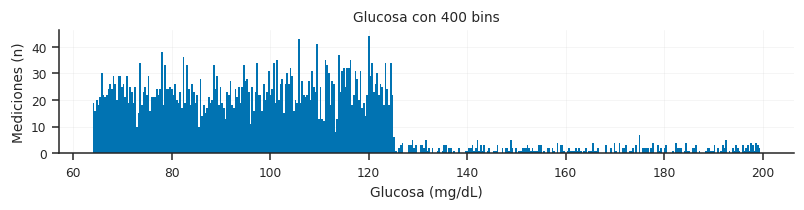

Glucosa: 10.6% de valores enteros | n en el mínimo (64) = 2 | n en el máximo (199.5) = 1
  valores distintos: 862 sobre 4,611 mediciones



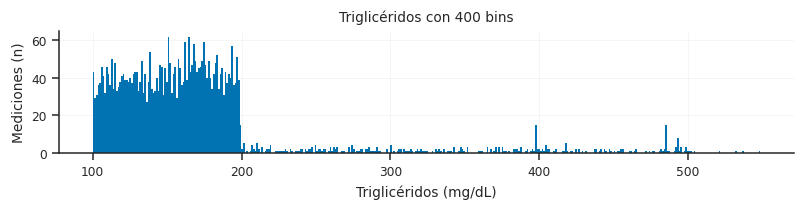

Triglicéridos: 10.4% de valores enteros | n en el mínimo (100) = 2 | n en el máximo (548.6) = 1
  valores distintos: 1274 sobre 4,028 mediciones



In [90]:
for analito in ['Frecuencia cardíaca', 'PA sistólica', 'Frecuencia respiratoria',
                'Glucosa', 'Triglicéridos']:
    s = num.loc[num['analito'] == analito, 'VALUE_num'].dropna()
    if s.empty:
        continue
    u = UNIDADES.get(analito, '')
    fig, ax = plt.subplots(figsize=(ANCHO_2COL, 1.8))
    ax.hist(s, bins=400, color=PALETA[0], edgecolor='none')
    ax.set_xlabel(f'{analito} ({u})')
    ax.set_ylabel('Mediciones (n)')
    ax.set_title(f'{analito} con 400 bins', fontsize=9)
    plt.show()

    # Contraste numérico 1: ¿los valores son enteros?
    enteros = float((s % 1 == 0).mean())
    # Contraste numérico 2: ¿hay masa apilada en el borde?
    en_min = int((s == s.min()).sum())
    en_max = int((s == s.max()).sum())
    print(f'{analito}: {enteros:.1%} de valores enteros | '
          f'n en el mínimo ({s.min():g}) = {en_min} | '
          f'n en el máximo ({s.max():g}) = {en_max}')
    print(f'  valores distintos: {s.nunique()} sobre {len(s):,} mediciones\n')


### Sonda C — Presencia informativa: cuándo se mide, no cuánto vale

Histograma de `dias_desde_indice`. Si aparece un pico en el día 0, las mediciones no se
distribuyen en el tiempo: se disparan en el encuentro diagnóstico. Consecuencia directa
para cualquier modelo posterior — *tener* una HbA1c es en sí mismo un predictor, y un
modelo entrenado sobre pacientes con HbA1c está entrenado sobre pacientes que recibieron
atención, no sobre pacientes con diabetes.

`describe()` sobre `VALUE_num` no puede ver esto: el problema no está en los valores,
está en las fechas.


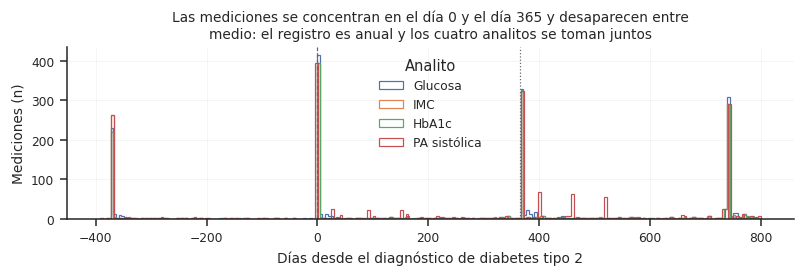

mediciones a <=15 días de un aniversario del diagnóstico: 40.8%
mediciones exactamente en el día 0                     : 9.2%


In [91]:
sub = obs_c[obs_c['dias_desde_indice'].between(-400, 800)]

fig, ax = plt.subplots(figsize=(ANCHO_2COL, 2.4))
for analito, d in sub.groupby('analito', observed=True):
    if analito not in ('HbA1c', 'Glucosa', 'PA sistólica', 'IMC'):
        continue
    ax.hist(d['dias_desde_indice'], bins=240, histtype='step', lw=1.1,
            label=str(analito))
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.axvline(365, color='0.4', ls=':', lw=0.8)
ax.set_xlabel('Días desde el diagnóstico de diabetes tipo 2')
ax.set_ylabel('Mediciones (n)')
ax.legend(title='Analito')
ax.set_title('Las mediciones se concentran en el día 0 y el día 365 y desaparecen entre\n'
             'medio: el registro es anual y los cuatro analitos se toman juntos',
             fontsize=9)
plt.show()

# Cuantificación del patrón: qué fracción cae a menos de 15 días de un múltiplo de 365
d = obs_c['dias_desde_indice']
dist = (d % 365).where((d % 365) <= 182, 365 - (d % 365))
print('mediciones a <=15 días de un aniversario del diagnóstico:',
      f'{(dist.abs() <= 15).mean():.1%}')
print('mediciones exactamente en el día 0                     :',
      f'{(d == 0).mean():.1%}')


### Sonda D — Estructura bivariada: sistólica vs. diastólica

Las dos marginales pueden ser impecables y la relación entre ambas ser imposible. Se
grafica la nube con densidad (hexbin, `viridis`) y se marca la diagonal
sistólica = diastólica: cualquier punto por debajo es físicamente imposible.


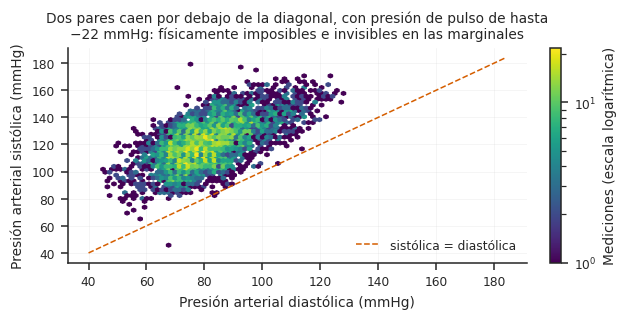

presión de pulso — mín: -22.0 mmHg
pares con sistólica <= diastólica: 2 de 4,746 (0.042 %)

Los pares imposibles:
analito                                          PA diastólica  PA sistólica
PATIENT                              FECHA                                  
9aab63bf-83af-04d0-90e4-90b237e17d72 2025-03-02      67.699997     45.700001
fd46c2b9-4dd7-ea06-a867-9d10765dd1af 2021-11-24      84.000000     82.000000


In [92]:
pa = (obs_c[obs_c['analito'].isin(['PA sistólica', 'PA diastólica'])]
      .pivot_table(index=['PATIENT', 'FECHA'], columns='analito',
                   values='VALUE_num', aggfunc='max', observed=True)
      .dropna())

fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.6, 2.8))
hb2 = ax.hexbin(pa['PA diastólica'], pa['PA sistólica'],
                gridsize=55, cmap=CMAP, bins='log', mincnt=1)
lim = [pa.min().min() - 5, pa.max().max() + 5]
ax.plot(lim, lim, color=PALETA[3], lw=1, ls='--', label='sistólica = diastólica')
ax.set_xlabel('Presión arterial diastólica (mmHg)')
ax.set_ylabel('Presión arterial sistólica (mmHg)')
ax.legend(loc='lower right')
fig.colorbar(hb2, ax=ax, label='Mediciones (escala logarítmica)')
ax.set_title('Dos pares caen por debajo de la diagonal, con presión de pulso de hasta\n'
             '−22 mmHg: físicamente imposibles e invisibles en las marginales',
             fontsize=9)
plt.show()

pp = pa['PA sistólica'] - pa['PA diastólica']
print('presión de pulso — mín:', round(float(pp.min()), 1), 'mmHg')
print('pares con sistólica <= diastólica:', int((pp <= 0).sum()),
      f'de {len(pa):,} ({100 * (pp <= 0).mean():.3f} %)')
print('\nLos pares imposibles:')
print(pa[pp <= 0].round(1).to_string())


### Los dos problemas reportados

**Hallazgo 1 — El registro es anual y sincronizado, no continuo (Sonda C).**

*Qué se ve.* El histograma de tiempos de medición respecto del diagnóstico muestra dos
espigas verticales, en el día 0 y alrededor del día 365, y prácticamente nada en el
medio. Las cuatro curvas —HbA1c, glucosa, presión sistólica e IMC— se superponen: los
cuatro analitos se registran el mismo día.

*Por qué `describe()` no lo muestra.* El resumen numérico se aplica a `VALUE_num`, y los
valores son perfectamente normales. El problema no está en **cuánto vale** la medición
sino en **cuándo se tomó**, y ninguna estadística descriptiva de la columna de valores
puede alcanzarlo. Aun aplicando `describe()` a la columna de fechas, se obtendrían
mínimo, máximo y cuartiles: ninguno de esos estadísticos distingue una distribución
uniforme de una concentrada en dos picos.

*Consecuencia.* Tres, en orden de gravedad. Primero, **cualquier agrupamiento temporal
más fino que un año fabrica ruido**: es exactamente lo que ocurrió con la primera
versión de la figura 3.2, donde los bins trimestrales producían puntos con menos de
treinta pacientes intercalados entre puntos con casi cuatrocientos, y el zigzag
resultante se leía como variabilidad clínica cuando era artefacto del binning. Segundo,
**no hay datos para estudiar variación intra-anual**: ni control glucémico estacional,
ni respuesta temprana al tratamiento, ni nada que ocurra entre dos controles. Tercero,
la sincronización perfecta entre analitos **elimina la posibilidad de estudiar la
ausencia informativa**, porque en estos datos un paciente tiene los catorce estudios o
no tiene ninguno.

---

**Hallazgo 2 — Los valores están discretizados y saturados en límites redondos
(Sonda B).**

*Qué se ve.* Con 400 bins, la frecuencia cardíaca y las dos presiones aparecen como
peines de valores enteros exactos, sin ningún valor intermedio. La frecuencia
respiratoria toma un puñado de valores enteros. Y varios analitos tienen **bordes
verticales en números redondos**: la glucosa forma un bloque plano que se corta
abruptamente y reaparece como una cola uniforme fina hasta detenerse en 200 mg/dL; los
triglicéridos tienen un piso exacto en 100 mg/dL.

*Por qué `describe()` no lo muestra.* El resumen informa el mínimo, el máximo y los
cuartiles, que son compatibles con una distribución continua y suave. No informa
**cuántas observaciones distintas hay** ni **cuánta masa se acumula exactamente en el
valor extremo**. Una distribución con 40 valores únicos y una con 4000 pueden tener
idéntica media, desviación, mediana y rango.

*Consecuencia.* Las colas de estas variables **no faltan: están apiladas contra el
borde**. Eso sesga a la baja cualquier estimación de varianza y de percentiles
extremos, e invalida cualquier modelado que suponga una distribución continua. Además,
la discretización a valores enteros es la firma de la captura manual frente a la
automática: en un EHR real este mismo patrón permitiría distinguir qué mediciones vienen
de un monitor y cuáles fueron transcritas a mano, que es una variable de calidad con
valor propio.

---

**Las dos sondas restantes, y qué informan.**

**Sonda A (bimodalidad).** No detecta el modo de fallo que buscaba —mezcla de
poblaciones pediátrica y adulta— porque el criterio de edad ≥ 18 años lo elimina por
construcción. Pero el **colesterol total sí resulta bimodal**, con dos modas en torno a
160 y 215 mg/dL, y el HDL muestra un hombro. La media de 203.7 mg/dL no describe bien a
ninguno de los dos subgrupos. No se reporta como hallazgo principal porque la
explicación probable no es un defecto de los datos sino el efecto del tratamiento
hipolipemiante, que en la cohorte separa a los tratados de los no tratados. Verificarlo
requeriría la tabla `medications`, que queda fuera del alcance de este laboratorio.

**Sonda D (estructura bivariada).** Detecta **2 pares sobre 4751** con presión sistólica
menor o igual a la diastólica, con una presión de pulso mínima de −22 mmHg. Son
físicamente imposibles y son invisibles en las distribuciones marginales, que están
ambas íntegramente dentro de rango. Es un hallazgo válido pero de magnitud despreciable
(0.04 %), y por eso no se eleva a hallazgo principal. Su valor es metodológico:
demuestra que dos columnas individualmente impecables pueden ser conjuntamente
imposibles, que es la razón por la que el Data Quality Dashboard de OHDSI incluye
chequeos de coherencia entre campos además de rangos por campo.


---
## Actividad 5 — Figura multipanel 2×2

Cuatro paneles que cubren cuatro tipos de pregunta distintos: distribución univariada,
trayectoria temporal, ranking categórico y densidad bivariada. Repetir cuatro veces el
mismo tipo de gráfica desperdicia el formato multipanel.

Decisiones de composición:

- **`figsize=(7.2, 5.4)`** — ancho de dos columnas de revista, en pulgadas.
- **Etiquetas A–D** en la esquina superior izquierda de cada panel, en negrita: es la
  convención para poder referirse a ellos desde el texto ("como muestra la Fig. 1C").
- **Dependencia de celdas:** el panel D reutiliza `pa` y `lim`, definidos en la Sonda D
  de la Actividad 4. Si borrás esa celda, movéle el cálculo acá.
- **`ax.set_rasterized(True)` en el panel del hexbin** — un hexbin con miles de celdas
  produce un PDF enorme si se guarda vectorial. Rasterizar *ese Axes* mantiene el texto
  y los ejes como vectores y convierte solo la nube en píxeles. Es el compromiso estándar
  para figuras densas.


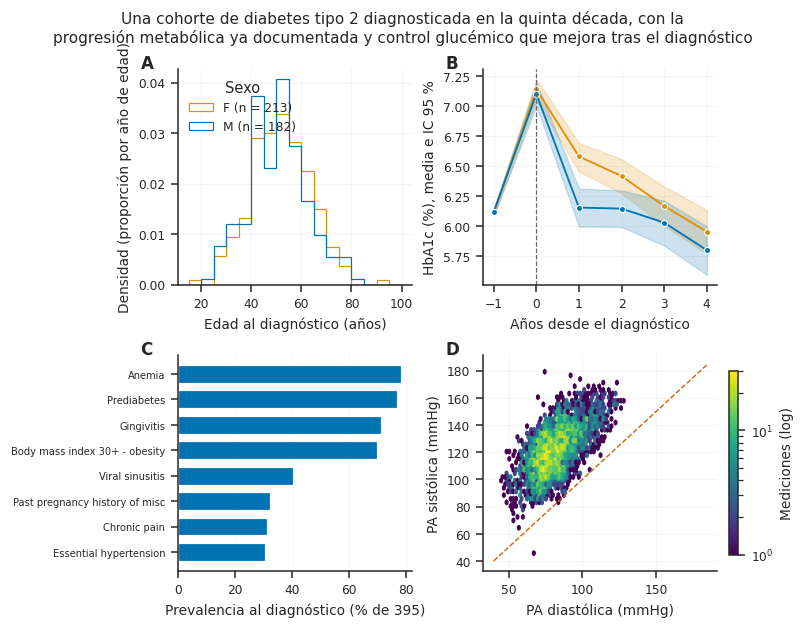

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(ANCHO_2COL, 5.6))
axA, axB, axC, axD = axes.ravel()

# --- A: edad al diagnóstico por sexo ---
for sexo, d in coh.groupby('GENDER', observed=True):
    axA.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
             histtype='step', lw=1.5, color=COLOR_SEXO.get(sexo),
             label=f'{sexo} (n = {len(d):,})')
axA.set_xlabel('Edad al diagnóstico (años)')
axA.set_ylabel('Densidad (proporción por año de edad)')
axA.legend(title='Sexo', loc='upper left')

# --- B: HbA1c relativa al diagnóstico (agrupamiento anual, ver 3.2) ---
sns.lineplot(data=hb, x='anio_rel', y='VALUE_num', hue='GENDER', palette=COLOR_SEXO,
             errorbar=('ci', 95), n_boot=1000, seed=0, marker='o', markersize=4,
             legend=False, ax=axB)
axB.axvline(0, color='0.4', ls='--', lw=0.8)
axB.set_xlabel('Años desde el diagnóstico')
axB.set_ylabel('HbA1c (%), media e IC 95 %')
axB.set_xticks(sorted(hb['anio_rel'].unique()))

# --- C: comorbilidades ---
o = prev.sort_values().tail(8)
axC.barh([str(i).replace(' (disorder)', '').replace(' (finding)', '')
               .replace(' (situation)', '')[:30] for i in o.index],
         o.values, color=PALETA[0], height=0.7)
axC.set_xlabel(f'Prevalencia al diagnóstico (% de {len(COHORTE):,})')
axC.grid(axis='y', visible=False)
axC.tick_params(axis='y', labelsize=6.5)

# --- D: sistólica vs diastólica ---
h = axD.hexbin(pa['PA diastólica'], pa['PA sistólica'], gridsize=45,
               cmap=CMAP, bins='log', mincnt=1, rasterized=True)
axD.plot(lim, lim, color=PALETA[3], lw=0.9, ls='--')
axD.set_xlabel('PA diastólica (mmHg)')
axD.set_ylabel('PA sistólica (mmHg)')
fig.colorbar(h, ax=axD, label='Mediciones (log)', shrink=0.85)
axD.set_rasterized(True)

for letra, ax in zip('ABCD', (axA, axB, axC, axD)):
    ax.text(-0.16, 1.07, letra, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')

fig.suptitle('Una cohorte de diabetes tipo 2 diagnosticada en la quinta década, con la\n'
             'progresión metabólica ya documentada y control glucémico que mejora tras '
             'el diagnóstico', fontsize=10)
plt.show()


---
## Actividad 6 — La misma figura en matplotlib, seaborn y plotly

Se replica el **panel B** (HbA1c media con IC 95 % por sexo). Se elige ésa
deliberadamente: es una figura con una **capa estadística**, y ahí es donde las tres
herramientas dejan de ser equivalentes. Si se comparara un simple diagrama de barras, las
tres se verían igual de bien y la comparación no enseñaría nada.

### 6.1 matplotlib puro


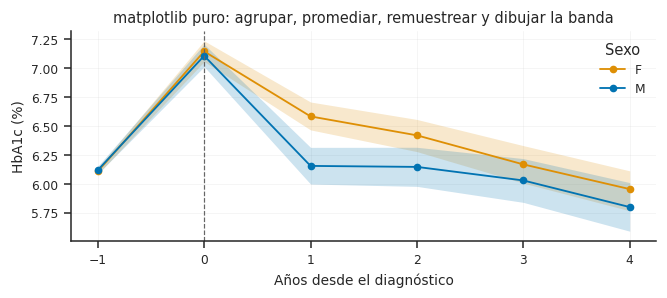

In [94]:
def ic95_bootstrap(x, n_boot=1000, rng=None):
    # IC 95 % de la media por bootstrap percentil.
    rng = np.random.default_rng(0) if rng is None else rng
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan, np.nan
    medias = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return np.percentile(medias, [2.5, 97.5])


fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.7, 2.6))
for sexo, d in hb.groupby('GENDER', observed=True):
    resumen_sexo = []
    for b, x in d.groupby('anio_rel', observed=True)['VALUE_num']:
        lo, hi = ic95_bootstrap(x)
        resumen_sexo.append({'anio_rel': b, 'media': x.mean(), 'lo': lo, 'hi': hi})
    r = pd.DataFrame(resumen_sexo).sort_values('anio_rel')
    ax.plot(r['anio_rel'], r['media'], marker='o', markersize=4,
            color=COLOR_SEXO.get(sexo), label=str(sexo))
    ax.fill_between(r['anio_rel'], r['lo'], r['hi'],
                    color=COLOR_SEXO.get(sexo), alpha=0.2, linewidth=0)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('Años desde el diagnóstico')
ax.set_ylabel('HbA1c (%)')
ax.set_xticks(sorted(hb['anio_rel'].unique()))
ax.legend(title='Sexo')
ax.set_title('matplotlib puro: agrupar, promediar, remuestrear y dibujar la banda')
plt.show()


### 6.2 seaborn


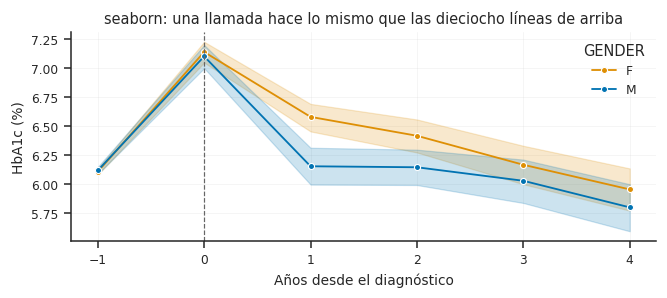

In [95]:
fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.7, 2.6))
sns.lineplot(data=hb, x='anio_rel', y='VALUE_num', hue='GENDER', palette=COLOR_SEXO,
             errorbar=('ci', 95), n_boot=1000, seed=0, marker='o', markersize=4, ax=ax)
ax.axvline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('Años desde el diagnóstico')
ax.set_ylabel('HbA1c (%)')
ax.set_xticks(sorted(hb['anio_rel'].unique()))
ax.set_title('seaborn: una llamada hace lo mismo que las dieciocho líneas de arriba')
plt.show()


### 6.3 plotly

plotly **no tiene** una capa de agregación estadística equivalente: `px.line` dibuja lo
que se le da. El intervalo hay que calcularlo aparte —reutilizando la función del
apartado 6.1— y dibujarlo como dos trazas con relleno. Eso es en sí mismo el resultado de
la comparación.


In [96]:
import plotly.graph_objects as go

resumen = []
for sexo, d in hb.groupby('GENDER', observed=True):
    for b, x in d.groupby('anio_rel', observed=True)['VALUE_num']:
        lo, hi = ic95_bootstrap(x)
        resumen.append({'GENDER': str(sexo), 'anio_rel': b, 'media': float(np.mean(x)),
                        'lo': lo, 'hi': hi, 'n': len(x)})
resumen = pd.DataFrame(resumen).sort_values(['GENDER', 'anio_rel'])

fig = go.Figure()
for sexo, d in resumen.groupby('GENDER'):
    c = mpl.colors.to_hex(COLOR_SEXO.get(sexo, PALETA[0]))
    fig.add_trace(go.Scatter(
        x=list(d['anio_rel']) + list(d['anio_rel'][::-1]),
        y=list(d['hi']) + list(d['lo'][::-1]),
        fill='toself', fillcolor=c, opacity=0.18,
        line={'width': 0}, hoverinfo='skip', showlegend=False))
    fig.add_trace(go.Scatter(
        x=d['anio_rel'], y=d['media'], name=str(sexo), mode='lines+markers',
        line={'color': c, 'width': 2}, customdata=d[['n']],
        hovertemplate='Año %{x}<br>HbA1c %{y:.2f} %<br>n = %{customdata[0]}'
                      '<extra></extra>'))

fig.update_layout(
    template='simple_white', width=560, height=340,
    title='plotly: el intervalo hay que calcularlo aparte',
    xaxis_title='Años desde el diagnóstico', yaxis_title='HbA1c (%)',
    legend_title='Sexo', margin={'l': 60, 'r': 20, 't': 50, 'b': 50})
fig.add_vline(x=0, line_dash='dash', line_color='gray', line_width=1)
fig.show()


### 6.4 Comparación

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Líneas para esta figura | ~18 | ~6 | ~22 (+ la función de IC) |
| Quién calcula el IC | vos | la librería | vos |
| Control fino | total | el que hereda de matplotlib | limitado y con otra API |
| Facetado | a mano con `subplots` | `col=` / `row=` | `facet_col=` en `express` |
| Exportable a PDF vectorial | sí, nativo | sí (devuelve objetos matplotlib) | requiere `kaleido`, y el resultado es peor |
| Aporta | reproducibilidad exacta y control | velocidad de iteración | *hover* con el `n` y zoom |

**Conclusión.** La pregunta no es cuál es mejor sino dónde conviene cada una, y la
respuesta la determina la **capa estadística**, que es lo que distingue a esta figura de
un gráfico de barras.

**seaborn para explorar.** Las seis líneas de `lineplot` hacen agrupamiento, cálculo de
la media e intervalo por bootstrap. Escribir esas tres cosas a mano —como exige el
apartado 6.1— multiplica las oportunidades de equivocarse sin agregar nada al
resultado. En la fase donde se prueban diez versiones de una figura, esa diferencia es
lo que domina.

**matplotlib para la figura final.** En cuanto la figura pasa a ser un entregable,
aparecen requisitos que seaborn no expone: rasterizar un solo panel y no el resto,
posicionar las etiquetas A–D, anotar el `n` sobre cada punto. Todo eso se hace sobre los
objetos `Figure` y `Axes`, y como seaborn devuelve precisamente esos objetos, no hay que
elegir: se explora arriba y se baja a ajustar.

**plotly para cazar atípicos, nunca como entregable.** El `hover` con el `n` de cada
punto y el zoom resuelven un problema real —identificar qué paciente produce un valor
raro— que las otras dos no resuelven. Pero requiere calcular el intervalo por fuera,
produce archivos pesados y su exportación vectorial es peor. En un PDF para una revista
no tiene lugar.

**El matiz de 6.1 frente a 6.2, que es el más importante.** Las bandas de matplotlib y
de seaborn no son idénticas aunque ambas sean IC 95 % por bootstrap: el remuestreo usa
semillas e implementaciones distintas. La comparación funciona acá como control: las dos
bandas se superponen ampliamente y la conclusión sobre la trayectoria de la HbA1c es la
misma en ambas. Si no lo fuera, la conclusión no estaría sostenida por los datos sino
por la elección de librería.


---
## Actividad 7 — Tabla 1

La tabla de características basales. Cuatro decisiones que la hacen defendible:

1. **Estratificación por sexo.** Es una descripción, no una comparación de tratamiento.
2. **Variables asimétricas en mediana [IQR]**, no en media ± DE. Días de seguimiento,
   triglicéridos y glucosa tienen colas largas; reportar una media ahí describe mal a la
   población. Se declaran en `nonnormal`.
3. **SMD en lugar de valor p.** Es la convención en investigación con datos del mundo
   real (Austin 2009, y es lo que reporta OHDSI). Motivo: el valor p depende del tamaño
   muestral, de modo que con `n` grande cualquier diferencia trivial resulta
   "significativa" y con `n` chico una diferencia clínicamente relevante no lo es. La SMD
   mide **magnitud** y es independiente del `n`; el umbral convencional es 0.1.
4. **`missing=True`.** La tabla reporta cuántos valores faltan en cada variable. Una
   Tabla 1 que no declara sus faltantes esconde a quién describe realmente.


In [97]:
tab = coh[['PATIENT', 'GENDER', 'RACE', 'ETHNICITY', 'edad_indice',
           'dias_seguimiento', 'fallecido']].copy()
tab = tab.merge(basal, left_on='PATIENT', right_index=True, how='left')

# Número de encuentros previos al índice: proxy de contacto con el sistema de salud
enc2 = enc[['PATIENT', 'START']].copy()
enc2['PATIENT'] = enc2['PATIENT'].astype(str)
enc2['START'] = a_dia_naive(enc2['START'])
enc2 = enc2[enc2['PATIENT'].isin(COHORTE)].merge(
    coh[['PATIENT', 'fecha_indice']], on='PATIENT', how='inner')
n_enc = (enc2[enc2['START'] <= enc2['fecha_indice']]
         .groupby('PATIENT').size().rename('n_encuentros_previos'))
tab = tab.merge(n_enc, left_on='PATIENT', right_index=True, how='left')
tab['n_encuentros_previos'] = tab['n_encuentros_previos'].fillna(0)

# Número de comorbilidades clínicas previas (códigos distintos, ver limitación)
n_com = (comorb[es_clinica].groupby('PATIENT')['CODE']
         .nunique().rename('n_comorbilidades'))
tab = tab.merge(n_com, left_on='PATIENT', right_index=True, how='left')
tab['n_comorbilidades'] = tab['n_comorbilidades'].fillna(0)

tab = tab.drop(columns='PATIENT')

# ── Saneamiento de tipos ANTES de construir la tabla ─────────────────────────
# Tres conversiones, y cada una evita un problema concreto:
#  1) float32 -> float64: float32 arrastra ruido de representación (191.600006) que
#     ensucia los decimales de la tabla y de los cuantiles.
#  2) category -> str: tras filtrar de 23 018 a 395 pacientes, RACE y ETHNICITY
#     conservan categorías sin usar. Un groupby sobre ellas genera grupos vacíos, que
#     es el origen de los FutureWarning de `observed=False` y de los errores de
#     alineación de índices en tableone.
#  3) bool -> texto: hace explícito que es una variable categórica de dos niveles.
for c in tab.select_dtypes('float32').columns:
    tab[c] = tab[c].astype('float64')
for c in tab.select_dtypes('category').columns:
    tab[c] = tab[c].astype(str)
tab['fallecido'] = tab['fallecido'].map({True: 'Sí', False: 'No'})

print(tab.shape)
print(tab.dtypes.value_counts().to_string())
tab.head()


(395, 22)
float64    15
object      4
int64       3


,GENDER,RACE,ETHNICITY,edad_indice,dias_seguimiento,fallecido,Colesterol total,Creatinina,Frecuencia cardíaca,Frecuencia respiratoria,...,HbA1c,IMC,LDL,PA diastólica,PA sistólica,Peso,Talla,Triglicéridos,n_encuentros_previos,n_comorbilidades
0,M,white,nonhispanic,37.218344,1102,No,191.600006,1.3,95.0,15.0,...,7.3,29.200001,112.300003,114.0,151.0,91.400002,177.000000,147.800003,10,14
1,M,asian,nonhispanic,42.028747,3258,No,199.899994,1.1,82.0,16.0,...,6.9,27.299999,121.500000,102.0,122.0,77.900002,168.800003,123.599998,5,5
2,F,white,nonhispanic,54.064339,1007,Sí,166.600006,1.0,76.0,14.0,...,7.6,30.299999,87.199997,48.0,95.0,79.300003,161.899994,145.699997,41,13
3,F,white,nonhispanic,56.191650,1918,No,197.199997,1.2,84.0,14.0,...,6.8,27.100000,142.000000,71.0,101.0,86.199997,178.300003,142.000000,18,11
4,M,white,nonhispanic,40.016427,2047,No,203.000000,1.9,91.0,13.0,...,7.3,29.100000,127.400002,100.0,130.0,96.300003,181.899994,135.300003,8,7


In [98]:
continuas = [c for c in tab.columns
             if pd.api.types.is_numeric_dtype(tab[c]) and tab[c].nunique() > 8]
categoricas = ['RACE', 'ETHNICITY', 'fallecido']

# Asimétricas -> mediana [IQR]. Se elige por la asimetría OBSERVADA, no por defecto:
# reportar una media sobre una variable con cola larga describe mal a la población.
asimetria = tab[continuas].skew().abs().sort_values(ascending=False)
print('asimetría absoluta por variable:')
print(asimetria.round(2).to_string())
no_normales = asimetria[asimetria > 1].index.tolist()
print('\nse reportan como mediana [IQR]:', no_normales)


asimetría absoluta por variable:
n_encuentros_previos    9.91
Triglicéridos           5.78
Glucosa                 2.43
Creatinina              1.83
IMC                     1.23
n_comorbilidades        0.97
Colesterol total        0.95
LDL                     0.81
HDL                     0.75
Peso                    0.49
PA diastólica           0.35
HbA1c                   0.21
edad_indice             0.16
Talla                   0.12
dias_seguimiento        0.06
Frecuencia cardíaca     0.03
PA sistólica            0.01

se reportan como mediana [IQR]: ['n_encuentros_previos', 'Triglicéridos', 'Glucosa', 'Creatinina', 'IMC']


In [99]:
ETIQUETAS = {
    'edad_indice': 'Edad al diagnóstico, años',
    'dias_seguimiento': 'Seguimiento tras el diagnóstico, días',
    'n_encuentros_previos': 'Encuentros previos al diagnóstico, n',
    'n_comorbilidades': 'Comorbilidades previas, n',
    'fallecido': 'Fallecido durante el seguimiento',
    'RACE': 'Raza', 'ETHNICITY': 'Etnia',
    'HbA1c': 'HbA1c basal, %', 'IMC': 'IMC basal, kg/m²',
    'Peso': 'Peso basal, kg', 'Talla': 'Talla basal, cm',
    'PA sistólica': 'PA sistólica basal, mmHg',
    'PA diastólica': 'PA diastólica basal, mmHg',
    'Glucosa': 'Glucosa basal, mg/dL', 'Creatinina': 'Creatinina basal, mg/dL',
    'Colesterol total': 'Colesterol total basal, mg/dL',
    'HDL': 'HDL basal, mg/dL', 'LDL': 'LDL basal, mg/dL',
    'Triglicéridos': 'Triglicéridos basales, mg/dL',
    'Frecuencia cardíaca': 'Frecuencia cardíaca basal, lpm',
    'Frecuencia respiratoria': 'Frecuencia respiratoria basal, rpm',
}

from tableone import TableOne

tabla1 = None
try:
    tabla1 = TableOne(
        tab,
        columns=continuas + categoricas,
        categorical=categoricas,
        nonnormal=no_normales,
        groupby='GENDER',
        rename=ETIQUETAS,
        smd=True,        # magnitud de la diferencia, independiente del n
        pval=False,      # ver justificación arriba
        missing=True,
        decimals=1,
    )
    tabla1_df = tabla1.tableone
    print('Tabla 1 construida con `tableone`')
except Exception as e:                                   # noqa: BLE001
    print('tableone falló:', type(e).__name__, e)
    print('Se usa la implementación propia de la celda siguiente.')


Tabla 1 construida con `tableone`


#### Implementación propia como respaldo, y por qué conviene tenerla

`tableone` falló en una primera ejecución con `InvalidIndexError`, un error interno de
alineación de índices que aparece al agrupar sobre columnas `category` con categorías
sin usar. El saneamiento de tipos de la celda anterior debería resolverlo, pero se
implementa la tabla también a mano por dos razones que van más allá del respaldo:

1. **La SMD es una fórmula de dos líneas.** Depender de una librería para algo que se
   puede escribir y verificar directamente hace más difícil defender el número.
2. **Deja explícita la decisión de qué resumen usa cada variable.** En una tabla
   generada por una librería, la elección entre media ± DE y mediana [IQR] queda
   escondida en un argumento.

Fórmulas empleadas, ambas de Austin (2009):

- Continuas: SMD = (x̄₁ − x̄₂) / √((s₁² + s₂²) / 2)
- Binarias:  SMD = (p₁ − p₂) / √((p₁(1−p₁) + p₂(1−p₂)) / 2)


In [100]:
def _smd_continua(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    var = (a.var(ddof=1) + b.var(ddof=1)) / 2
    return np.nan if var == 0 else (a.mean() - b.mean()) / np.sqrt(var)


def _smd_proporcion(p1, p2):
    var = (p1 * (1 - p1) + p2 * (1 - p2)) / 2
    return np.nan if var == 0 else (p1 - p2) / np.sqrt(var)


def tabla_basal(df, grupo, continuas, categoricas, nonnormal, etiquetas, dec=1):
    # Tabla 1 estratificada con SMD. Devuelve un DataFrame listo para exportar.
    niveles = sorted(df[grupo].dropna().unique())
    assert len(niveles) == 2, 'la SMD por pares requiere exactamente dos estratos'
    g1, g2 = (df[df[grupo] == n] for n in niveles)
    cols = ['Variable', 'Faltantes',
            f'Total (n={len(df)})',
            f'{niveles[0]} (n={len(g1)})', f'{niveles[1]} (n={len(g2)})', 'SMD']
    filas = []

    for c in continuas:
        if c in nonnormal:
            def fmt(s):
                s = s.dropna()
                return (f'{s.median():.{dec}f} '
                        f'[{s.quantile(.25):.{dec}f}–{s.quantile(.75):.{dec}f}]')
            sufijo = ', mediana [IQR]'
        else:
            def fmt(s):
                s = s.dropna()
                return f'{s.mean():.{dec}f} ({s.std():.{dec}f})'
            sufijo = ', media (DE)'
        filas.append({
            cols[0]: etiquetas.get(c, c) + sufijo,
            cols[1]: int(df[c].isna().sum()),
            cols[2]: fmt(df[c]), cols[3]: fmt(g1[c]), cols[4]: fmt(g2[c]),
            cols[5]: round(_smd_continua(g1[c], g2[c]), 3),
        })

    for c in categoricas:
        filas.append({cols[0]: etiquetas.get(c, c) + ', n (%)',
                      cols[1]: int(df[c].isna().sum()),
                      cols[2]: '', cols[3]: '', cols[4]: '', cols[5]: ''})
        for lvl in sorted(df[c].dropna().unique()):
            p1 = float((g1[c] == lvl).mean())
            p2 = float((g2[c] == lvl).mean())
            filas.append({
                cols[0]: f'    {lvl}', cols[1]: '',
                cols[2]: f'{int((df[c] == lvl).sum())} ({100 * (df[c] == lvl).mean():.{dec}f})',
                cols[3]: f'{int((g1[c] == lvl).sum())} ({100 * p1:.{dec}f})',
                cols[4]: f'{int((g2[c] == lvl).sum())} ({100 * p2:.{dec}f})',
                cols[5]: round(_smd_proporcion(p1, p2), 3),
            })
    return pd.DataFrame(filas, columns=cols)


tabla1_manual = tabla_basal(tab, 'GENDER', continuas, categoricas,
                            no_normales, ETIQUETAS)

# Verificación cruzada: la SMD de la edad debe coincidir con la de `tableone`
print('SMD de la edad (implementación propia):',
      tabla1_manual.loc[tabla1_manual['Variable'].str.startswith('Edad'), 'SMD'].iloc[0])
print('\nVariables con |SMD| > 0.1 (desbalance relevante entre sexos):')
smd_num = pd.to_numeric(tabla1_manual['SMD'], errors='coerce')
print(tabla1_manual.loc[smd_num.abs() > 0.1, ['Variable', 'SMD']].to_string(index=False))

tabla1_manual


SMD de la edad (implementación propia): 0.145

Variables con |SMD| > 0.1 (desbalance relevante entre sexos):
                                           Variable    SMD
              Edad al diagnóstico, años, media (DE)  0.145
  Seguimiento tras el diagnóstico, días, media (DE) -0.234
          Colesterol total basal, mg/dL, media (DE) -0.172
             Creatinina basal, mg/dL, mediana [IQR] -0.376
         Frecuencia cardíaca basal, lpm, media (DE) -0.141
                       HDL basal, mg/dL, media (DE)  0.469
                       LDL basal, mg/dL, media (DE) -0.212
                         Peso basal, kg, media (DE) -1.401
                        Talla basal, cm, media (DE) -1.799
        Triglicéridos basales, mg/dL, mediana [IQR] -0.261
Encuentros previos al diagnóstico, n, mediana [IQR]   0.29
              Comorbilidades previas, n, media (DE)  0.146
                                              asian   0.17
                                              white -0.116
      

,Variable,Faltantes,Total (n=395),F (n=213),M (n=182),SMD
0,"Edad al diagnóstico, años, media (DE)",0,51.0 (11.8),51.8 (11.8),50.1 (11.7),0.145
1,"Seguimiento tras el diagnóstico, días, media (DE)",0,1795.0 (801.6),1708.7 (763.9),1895.9 (834.4),-0.234
2,"Colesterol total basal, mg/dL, media (DE)",0,182.7 (42.9),179.3 (41.3),186.7 (44.6),-0.172
3,"Creatinina basal, mg/dL, mediana [IQR]",0,1.1 [0.9–1.3],0.9 [0.8–1.1],1.2 [1.1–1.4],-0.376
4,"Frecuencia cardíaca basal, lpm, media (DE)",0,80.5 (11.5),79.7 (11.1),81.4 (11.8),-0.141
5,"Glucosa basal, mg/dL, mediana [IQR]",0,83.8 [74.6–95.1],84.0 [75.3–95.7],83.5 [74.1–94.2],0.039
6,"HDL basal, mg/dL, media (DE)",0,51.0 (11.2),53.4 (9.1),48.2 (12.7),0.469
7,"HbA1c basal, %, media (DE)",0,7.2 (0.6),7.2 (0.6),7.2 (0.6),0.085
8,"IMC basal, kg/m², mediana [IQR]",0,28.4 [27.7–30.1],28.3 [27.7–30.1],28.5 [27.7–30.1],-0.002
9,"LDL basal, mg/dL, media (DE)",0,107.4 (44.0),103.2 (43.2),112.4 (44.4),-0.212


In [101]:
TAB1 = BASE03 / 'tabla1_cohorte_t2d'

tabla1_manual.to_csv(f'{TAB1}.csv', index=False)
tabla1_manual.to_html(f'{TAB1}.html', index=False)
print('Tabla 1 (implementación propia) exportada a', TAB1)

if tabla1 is not None:
    tabla1.to_csv(f'{TAB1}_tableone.csv')
    tabla1.to_html(f'{TAB1}_tableone.html')
    print('Tabla 1 (tableone) exportada como respaldo')


Tabla 1 (implementación propia) exportada a /content/drive/MyDrive/curso-cd-2027/lab03/tabla1_cohorte_t2d
Tabla 1 (tableone) exportada como respaldo


**Comentario de la Tabla 1.**

La cohorte son 395 adultos con diabetes tipo 2 incidente, 213 mujeres (53.9 %) y 182
varones (46.1 %), diagnosticados a una edad media de 51.8 y 50.1 años respectivamente.

**Sobre las SMD.** El umbral convencional de 0.1 marca desbalance relevante. Conviene
recordar qué significa acá: **no hay ningún tratamiento ni exposición que balancear**;
la estratificación por sexo es descriptiva. Una SMD alta no indica un problema del
estudio sino una diferencia real entre hombres y mujeres, y las diferencias esperables
—talla, peso, creatinina, HDL— deberían aparecer con SMD grandes. Si alguna de ellas
apareciera con SMD cercana a cero, **eso** sí sería un problema: indicaría que el
generador no reproduce el dimorfismo sexual de esas variables.

**Sobre la columna de faltantes.** Es cero en los catorce analitos basales, por
construcción del cuarto criterio de inclusión. Es un resultado deseable y a la vez la
señal de que estos datos no son un EHR: en un registro real, una Tabla 1 con 0 % de
faltantes en catorce laboratorios simultáneos no existe.

**Sobre `n_comorbilidades`.** Cuenta códigos SNOMED distintos previos al índice tras
excluir los conceptos no clínicos. No es un índice de comorbilidad validado y no debe
compararse con valores de Charlson publicados; ver la limitación 2 del cierre.


---
## Actividad 8 — Exportación

PDF vectorial (texto seleccionable y editable, tipografía embebida como TrueType) y PNG
a 300 dpi. Se reconstruye la figura dentro de una función: una figura que solo existe
como efecto secundario de una celda no es reproducible, y si el kernel se reinicia
desaparece.


In [102]:
def figura_principal():
    # Construye y devuelve la figura 2x2 del entregable.
    fig, axes = plt.subplots(2, 2, figsize=(ANCHO_2COL, 5.6))
    axA, axB, axC, axD = axes.ravel()

    for sexo, d in coh.groupby('GENDER', observed=True):
        axA.hist(d['edad_indice'], bins=np.arange(15, 105, 5), density=True,
                 histtype='step', lw=1.5, color=COLOR_SEXO.get(sexo),
                 label=f'{sexo} (n = {len(d):,})')
    axA.set_xlabel('Edad al diagnóstico (años)')
    axA.set_ylabel('Densidad (proporción por año de edad)')
    axA.legend(title='Sexo', loc='upper left')

    sns.lineplot(data=hb, x='anio_rel', y='VALUE_num', hue='GENDER',
                 palette=COLOR_SEXO, errorbar=('ci', 95), n_boot=1000, seed=0,
                 marker='o', markersize=4, legend=False, ax=axB)
    axB.axvline(0, color='0.4', ls='--', lw=0.8)
    axB.set_xlabel('Años desde el diagnóstico')
    axB.set_ylabel('HbA1c (%), media e IC 95 %')
    axB.set_xticks(sorted(hb['anio_rel'].unique()))

    o = prev.sort_values().tail(8)
    axC.barh([str(i).replace(' (disorder)', '').replace(' (finding)', '')
                   .replace(' (situation)', '')[:30] for i in o.index],
             o.values, color=PALETA[0], height=0.7)
    axC.set_xlabel(f'Prevalencia al diagnóstico (% de {len(COHORTE):,})')
    axC.grid(axis='y', visible=False)
    axC.tick_params(axis='y', labelsize=6.5)

    h = axD.hexbin(pa['PA diastólica'], pa['PA sistólica'], gridsize=45,
                   cmap=CMAP, bins='log', mincnt=1, rasterized=True)
    axD.plot(lim, lim, color=PALETA[3], lw=0.9, ls='--')
    axD.set_xlabel('PA diastólica (mmHg)')
    axD.set_ylabel('PA sistólica (mmHg)')
    fig.colorbar(h, ax=axD, label='Mediciones (log)', shrink=0.85)
    axD.set_rasterized(True)

    for letra, ax in zip('ABCD', (axA, axB, axC, axD)):
        ax.text(-0.16, 1.07, letra, transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

    fig.suptitle('Una cohorte de diabetes tipo 2 diagnosticada en la quinta década, con '
                 'la\nprogresión metabólica ya documentada y control glucémico que '
                 'mejora tras el diagnóstico', fontsize=10)
    return fig


fig = figura_principal()
fig.savefig(FIG / 'figura_principal.pdf')                 # vectorial, fuentes TrueType
fig.savefig(FIG / 'figura_principal.png', dpi=300)        # 300 dpi
plt.close(fig)

for f in sorted(FIG.iterdir()):
    print(f.name, '—', round(f.stat().st_size / 1024, 1), 'KB')


figura_principal.pdf — 124.0 KB
figura_principal.png — 438.7 KB


In [103]:
# Verificación de que el PDF salió vectorial y con las fuentes embebidas correctamente
!pdffonts "{FIG}/figura_principal.pdf" 2>/dev/null || echo 'pdffonts no disponible'

from PIL import Image
im = Image.open(FIG / 'figura_principal.png')
print('PNG:', im.size, 'px |', im.info.get('dpi'), 'dpi')
print('esperado:', round(ANCHO_2COL * 300), 'px de ancho aprox. (más el bbox tight)')


pdffonts no disponible
PNG: (2194, 1714) px | (299.9994, 299.9994) dpi
esperado: 2160 px de ancho aprox. (más el bbox tight)


En la salida de `pdffonts`, la columna `type` debe decir **TrueType** (o `Type 42`), no
`Type 3`. Type 3 es el default de matplotlib, no es editable en Illustrator y varias
revistas lo rechazan automáticamente en el envío. Lo evitamos con
`rcParams['pdf.fonttype'] = 42` en la sección 0.5.

Se exportan también las figuras individuales de las actividades 3 y 4, por si el revisor
las pide sueltas.


In [104]:
def exportar(fig, nombre):
    fig.savefig(FIG / f'{nombre}.pdf')
    fig.savefig(FIG / f'{nombre}.png', dpi=300)
    print('exportado:', nombre)

# Ejemplo: reconstruí y exportá las que quieras conservar sueltas.
# fig, ax = plt.subplots(...); ...; exportar(fig, 'fig02_hba1c_por_sexo')


---
## Extra (opcional) — Kaplan–Meier desde el diagnóstico

No lo pide el enunciado, pero es la figura clínica canónica de una cohorte con fecha
índice y es la que la sesión marca como obligatoria con **tabla de pacientes en riesgo**.
Sin esa tabla, la cola derecha de la curva puede estar sostenida por tres pacientes y no
hay forma de saberlo mirando.

Suma valor al portafolio y es transferible casi tal cual al proyecto final.


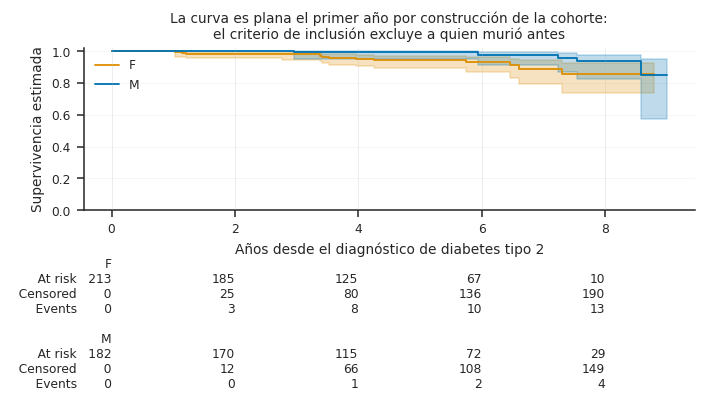

fallecidos durante el seguimiento: 18 de 395 (4.6 %)


In [105]:
HACER_KM = True

if HACER_KM:
    from lifelines import KaplanMeierFitter
    from lifelines.plotting import add_at_risk_counts

    coh['anios_seguimiento'] = coh['dias_seguimiento'] / 365.25
    fig, ax = plt.subplots(figsize=(ANCHO_1COL * 1.8, 3.6))
    ajustes = []
    for sexo, d in coh.groupby('GENDER', observed=True):
        km = KaplanMeierFitter(label=str(sexo))
        km.fit(d['anios_seguimiento'], event_observed=d['fallecido'])
        km.plot_survival_function(ax=ax, ci_show=True, color=COLOR_SEXO.get(sexo))
        ajustes.append(km)
    ax.set_xlabel('Años desde el diagnóstico de diabetes tipo 2')
    ax.set_ylabel('Supervivencia estimada')
    ax.set_ylim(0, 1.02)
    ax.set_title('La curva es plana el primer año por construcción de la cohorte:\n'
                 'el criterio de inclusión excluye a quien murió antes', fontsize=9)
    add_at_risk_counts(*ajustes, ax=ax)
    plt.show()

    print('fallecidos durante el seguimiento:', int(coh['fallecido'].sum()),
          f'de {len(coh)} ({100 * coh["fallecido"].mean():.1f} %)')


> **Advertencia obligatoria, y es la razón por la que esta figura se marca como
> ilustrativa y no como resultado.** El criterio de inclusión exige 365 días de
> seguimiento, de modo que **por construcción nadie puede morir antes del año**: el
> tramo plano inicial es un artefacto del diseño, no un hallazgo biológico. Es sesgo de
> supervivencia inducido por el criterio de inclusión.
>
> A eso se suma un segundo problema propio de esta cohorte: sólo 18 pacientes (4.6 %)
> fallecen durante el seguimiento, y el horizonte máximo es de 9 años con la mitad de la
> cohorte censurada antes de los 5. Con ese número de eventos, la cola derecha de la
> curva está sostenida por muy pocos pacientes —lo que la tabla de pacientes en riesgo
> debajo del eje hace visible, y es exactamente para eso que la sesión la marca como
> obligatoria—, y los intervalos de confianza son demasiado anchos para sostener
> ninguna comparación entre sexos.
>
> Para obtener una curva interpretable habría que eliminar el criterio de 365 días o
> arrancar el eje en t = 1 año, declarando la entrada diferida.


---
## Cierre — Tres hallazgos en lenguaje clínico

**Hallazgo 1 — Perfil de la cohorte.**
> Se identificaron 395 adultos con diabetes mellitus tipo 2 de nuevo diagnóstico y
> seguimiento documentado, 213 mujeres y 182 varones. La edad media al diagnóstico fue
> de 51.8 años en mujeres y 50.1 en varones, y la mitad de los pacientes permaneció en
> observación durante al menos cinco años. Tres de cada cuatro pacientes ya tenían
> registrada una prediabetes (76.7 %) o una obesidad (69.9 %) antes del diagnóstico, y
> tres de cada diez una hipertensión arterial (30.6 %). La progresión desde la
> alteración metabólica hasta la diabetes establecida estaba documentada en la historia
> clínica de la mayoría de estos pacientes antes de que se hiciera el diagnóstico.

**Hallazgo 2 — Trayectoria del control glucémico.**
> La hemoglobina glicosilada alcanzó su valor máximo en el momento del diagnóstico, con
> una media de 7.2 %, y descendió de forma sostenida en los años siguientes hasta
> aproximadamente 5.8 % al tercer año, sin diferencias apreciables entre sexos. El
> patrón es compatible con el efecto del tratamiento iniciado tras el diagnóstico. La
> interpretación debe ser cauta por dos motivos: la cohorte excluye a quienes murieron
> en el primer año, de modo que la trayectoria describe a los pacientes que
> sobrevivieron y siguieron en control; y el número de pacientes disminuye en cada año
> sucesivo, por lo que el descenso en el extremo derecho de la curva se apoya en una
> fracción de la cohorte original.

**Hallazgo 3 — Calidad del registro.**
> Las determinaciones de laboratorio y los signos vitales de esta base no se distribuyen
> a lo largo del seguimiento: se concentran en el día del diagnóstico y en sus
> aniversarios anuales, y los catorce parámetros analizados se registran siempre en el
> mismo contacto. En consecuencia, esta base **no permite estudiar ninguna variación que
> ocurra entre dos controles anuales** —respuesta temprana al tratamiento, variación
> estacional del control glucémico, descompensaciones intercurrentes—, y cualquier
> análisis que agrupe los datos en intervalos menores de un año producirá fluctuaciones
> que reflejan el calendario de controles y no la evolución de los pacientes.

---

### Limitaciones declaradas

1. **Datos sintéticos.** Synthea genera valores dentro de rango por construcción. El
   entregable de la Actividad 4 es el **procedimiento de detección**, no la tasa de
   error encontrada. Sobre un EHR real las mismas sondas detectarían errores de unidad,
   errores de tipeo y valores centinela.
2. **Comorbilidades por frecuencia de códigos, no por índice validado.** No es Charlson
   ni Elixhauser: es un conteo de códigos SNOMED sueltos con exclusión manual de
   conceptos sociales. La versión correcta recorre la jerarquía del vocabulario
   (`concept_ancestor`, sesión 16). Dos códigos que describen la misma entidad clínica
   cuentan aquí como comorbilidades distintas.
3. **Sesgo de supervivencia** por el criterio de ≥ 365 días de seguimiento. Afecta
   directamente a la curva de Kaplan–Meier y, en menor grado, a la trayectoria de la
   HbA1c.
4. **Restricción a la ventana de exportación.** El cuarto criterio de inclusión reduce
   la cohorte de 1682 a 395 pacientes y la restringe a los diagnósticos más recientes.
   Garantiza que todos tengan datos, pero la cohorte resultante no es una muestra
   aleatoria de los diabéticos del dataset.
5. **La ausencia informativa no es estudiable en estos datos**, porque los catorce
   analitos se generan juntos: un paciente los tiene todos o no tiene ninguno. Ningún
   método de imputación validado acá transferiría a un EHR real.
6. **Rangos de plausibilidad de origen mixto.** Los de signos vitales provienen de una
   fuente publicada [A]; los límites inferiores de las concentraciones son
   definicionales [B] y no requieren fuente; los antropométricos y los superiores son
   convencionales [C] y no citables, como ya se declaró en el lab02.
7. **El IMC registrado no es consistente con el peso y la talla registrados**, y el LDL
   es un valor calculado por Friedewald y no una medición. Ninguna de las dos columnas
   debería usarse como variable independiente sin declarar esa dependencia.

### Hacia dónde sigue esto

| En este lab | Se formaliza en |
|---|---|
| Fecha índice y criterios de inclusión | Diseño de cohortes en OMOP con SQL (sesión 17) |
| Período de observación reconstruido a mano | Tabla `observation_period` de OMOP (sesión 12) |
| Tabla de atrición | Feasibility y attrition tables en OHDSI (sesión 18) |
| Filtrar por código y no por texto | Vocabularios estándar: SNOMED, LOINC (sesiones 14–15) |
| Comorbilidades por jerarquía | `concept_relationship` y `concept_ancestor` (sesión 16) |
| Rangos de plausibilidad y coherencia entre campos | Data Quality Dashboard de OHDSI |
| Valores basales en ventana | Feature engineering clínico (sesión 23) |
| SMD como medida de balance | Evaluación clínica de modelos (sesión 25) |

---

### Entrega

```
s03-visualizacion-eda/
└── tu-entrega/
    ├── eda_cohorte.ipynb
    ├── eda_utils.py
    ├── test_eda_utils.py
    ├── tabla1_cohorte_t2d.csv / .html
    └── figuras/
        ├── figura_principal.pdf
        └── figura_principal.png
```

Pull request contra `main` con título
`lab03: EDA de cohorte de diabetes tipo 2 en Synthea`.

> **Antes de commitear: `Runtime → Restart session and run all`.** El notebook debe
> correr limpio de arriba abajo, con los contadores de ejecución en orden. Un notebook
> cuyos contadores saltan es un notebook cuyos resultados no se pueden reproducir, y es
> lo primero que mira un revisor.
